# Exploración inicial de los datos

**NOTA:**

Los ficheros están alojados como públicos en mi Google Drive.

- [licencias202312.csv](https://drive.google.com/file/d/1_6E0-HROhGgJTKbjcbajEAyfvuZlcHDD/view?usp=sharing) **(FILE_ID: 1_6E0-HROhGgJTKbjcbajEAyfvuZlcHDD)**.
- [locales202312.csv](https://drive.google.com/file/d/1WMovHctAKyjh0si6pOtYI9aq3Ki84Lxv/view?usp=sharing) **(FILE_ID: 1WMovHctAKyjh0si6pOtYI9aq3Ki84Lxv)**.
- [terrazas202312.csv](https://drive.google.com/file/d/1pt6S7cwdpHLoXj3d0WqTlOhwdHopKik9/view?usp=sharing) **(FILE_ID: 1pt6S7cwdpHLoXj3d0WqTlOhwdHopKik9)**.
- [actividadeconomica202312.csv](https://drive.google.com/file/d/1W7ewwd2Hdz14eo5lj57bVWInNotC9xmF/view?usp=sharing) **(FILE_ID: 1W7ewwd2Hdz14eo5lj57bVWInNotC9xmF)**.

Se puede acceder a la descarga directa de los ficheros a través de la URL `https://docs.google.com/uc?id=FILE_ID`. Ver: https://stackoverflow.com/questions/41980082/download-public-google-drive-files.

In [84]:
# Ver; https://pypi.org/project/haversine/
!pip install -qU haversine

In [85]:
from itertools import product, combinations
from pathlib import Path
from pyproj import Transformer
import folium
import inspect
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import unicodedata
from haversine import haversine

In [3]:
# Montamos drive para guardar los datasets resultantes
from google.colab import drive

drive.mount('/gdrive')

Mounted at /gdrive


In [4]:
ROOT = Path('/gdrive/MyDrive')

DATA_DIR = ROOT / 'nosql'
DATA_DIR.mkdir(parents=True, exist_ok=True)

Funciones auxiliares para explorar los datasets: revisar valores nulos, tipos de datos, frequencias y valores únicos.

In [7]:
def missing_data(data):
    """
    Función auxiliar para contabilizar el número de nulos de cada columna.
    """
    total = data.isna().sum()
    percent = (data.isna().sum()/len(data)*100)
    tipos = data.dtypes
    tt = pd.concat([total, percent, tipos], axis=1, keys=['Total', 'Porcentaje', 'Tipos'])
    return tt.transpose()

def check_types(data):
    """
    Función auxiliar para mostrar el tipos de datos y un ejemplo de cada columna.
    """
    return pd.DataFrame({'Valor ejemplo': data.iloc[0], 'Tipo': data.dtypes}).transpose()

def most_frequent_values(data):
    """
    Función auxliar para mostrar el valor más frecuente y su frecuencia de cada columna.
    """
    total = data.count()
    tt = pd.DataFrame({ 'Total': total })
    items = []
    values = []
    uniques = []
    for col in data.columns:
        try:
            item = data[col].value_counts().index[0]
            value = data[col].value_counts().values[0]
            items.append(item)
            values.append(value)
        except Exception as ex:
            print(f"Error en columna {col}: {ex}")
            items.append(0)
            values.append(0)
            continue
    tt['Valor más frecuente'] = items
    tt['Frecuencia'] = values
    tt['Porcentaje del total'] = np.round(tt['Frecuencia']/tt['Total']*100, 3)

    return tt.transpose()


def unique_values(data):
    """
    Función auxliar para mostrar el número de valores únicos de cada columna.
    """
    total = data.count()
    tt = pd.DataFrame({ 'Total': total })
    uniques = []
    for col in data.columns:
        uniques.append(data[col].nunique())
    tt['Valores únicos'] = uniques
    return tt.transpose()

Función auxiliar para normalizar los nombres de las columnas: minúsculas, sin espacios y con separación mediante guión bajo.

In [8]:
def normalize_column_name(col):
    """
    Función para normalizar el nombre de las columnas:
        lowercase, sin espacios, separación con guión bajo
    """
    col = col.lower()
    col = col.strip()
    col = re.sub(r'\s+', '_', col )
    return col

print("Ejemplos de normalización de las columnas:")
print("==========================================\n")
for col in "Fecha_Dec_Lic", "     Columna ficticia", "OTRA     COLUMNA":
    print(f"{col!r:^23} -> {normalize_column_name(col)!r}")

Ejemplos de normalización de las columnas:

    'Fecha_Dec_Lic'     -> 'fecha_dec_lic'
'     Columna ficticia' -> 'columna_ficticia'
  'OTRA     COLUMNA'    -> 'otra_columna'


`Pandas` permite visualizar hasta 20 columnas por defecto sin truncamiento.

In [9]:
print("Máximo de columnas por defecto: ", pd.get_option("display.max_columns"))

Máximo de columnas por defecto:  20


Modificamos este valor para que no haya límite de columnas en la visualización, ya que todos los ficheros que se van a analizar tiene más de 20 columnas.

In [10]:
pd.set_option("display.max_columns", None)

Vamos a recoger todas las modificaciones sugeridas en cada dataset en `clean_steps` utilizando la siguiente estructura:

```json
{
    "dataset": "fichero afectado",
    "column": "columna afectada",
    "ejemplo_valor": "valores de ejemplo",
    "impacto": "bajo|medio|alto",
    "accion_sugerida": "descripción de la acción sugerida",
    "funcion": "funcion que transforma los datos"
}
```

In [11]:
clean_steps = []

## Licencias

### Descripción del fichero

[Contenido y estructura de los ficheros de licencias](https://datos.madrid.es/dataset/200085-0-censo-locales/resource/200085-11-censo-locales).

#### Categoría: identificación y localización del local

| Campo | Descripción |
| :--- | :--- |
| `id_local` | Código numérico único del local. Se forma uniendo: Código del portal + secuencial (si es puerta de calle) o Código de agrupación + planta + local (si es agrupado). |
| `rotulo` | Nombre comercial del establecimiento. |
| `id_distrito_local` | Código numérico del distrito municipal. |
| `desc_distrito_local` | Nombre del distrito municipal. |
| `cod_barrio_local` | Código numérico del barrio (requiere el distrito para ser unívoco). |
| `id_barrio_local` | Código numérico del barrio (ya incluye el código de distrito). |
| `desc_barrio_local` | Nombre del barrio municipal. |
| `id_seccion_censal_local` | Código de distrito + sección censal. |
| `desc_seccion_censal_local`| Código de la sección censal. |


#### Categoría: estado y acceso del local

| Campo | Descripción |
| :--- | :--- |
| `id_tipo_acceso_local` | Código del tipo de acceso. *(Ver Tabla A)* |
| `desc_tipo_acceso_local` | Literal del tipo de acceso. *(Ver Tabla A)* |
| `id_situacion_local` | Código de la situación de actividad. *(Ver Tabla B)* |
| `desc_situacion_local` | Literal de la situación del local. *(Ver Tabla B)* |


#### Categoría: dirección del edificio y acceso real

> *Nota: Si el acceso al local es por el mismo vial que el del edificio, los datos del Bloque B repetirán los del Bloque A.*

**Bloque A: Dirección del Edificio (Portal principal)**

| Campo | Descripción |
| :--- | :--- |
| `id_ndp_edificio` | Código numérico oficial de la dirección. Ej: C/ Goya 24 = 11014430. |
| `id_clase_ndp_edificio`| `1` (Oficial/Normalizada) o `9` (No normalizada - *No debería aparecer*). |
| `id_vial_edificio` | Código que identifica la clase + nombre de la vía. |
| `clase_vial_edificio` | Tipo de vía (Calle, Avenida, Plaza…). |
| `desc_vial_edificio` | Nombre de la vía según el callejero oficial. |
| `nom_edificio` | Tipo de numeración (Número, Kilómetro, bloque…). |
| `num_edificio` | Número de la vía. |
| `cal_edificio` | Calificador del número (A, B…). Puede ser nulo. |
| `secuencial_local_PC` | Número secuencial en saltos decenales (10, 20...). Identifica el orden del local en la fachada de izquierda a derecha en sentido antihorario. |

**Bloque B: Dirección de Acceso al Local**

| Campo | Descripción |
| :--- | :--- |
| `id_ndp_acceso` a `cal_acceso`| Equivalentes a los campos del edificio, pero aplicados a la puerta por la que se entra físicamente al local. |


#### Categoría: coordenadas y agrupaciones

> *Nota: Para locales "Puerta de Calle", los campos de agrupación aparecerán con valor `-1` o "SIN AGRUPACION".*

| Campo | Descripción |
| :--- | :--- |
| `coordenadas x-y_local` | Coordenadas UTM del local "Puerta de Calle". *(ED-50 hasta 15/09/2017; ETRS89 posterior)*. **Inválidas si el acceso no es Puerta de Calle**. |
| `coordenadas x-y_agrupacion`| Coordenadas UTM de la entrada principal a la agrupación. |
| `id_agrupación` | Código asignado a la agrupación. |
| `nombre_agrupación` | Nombre comercial de la agrupación. |
| `id_tipo_agrup` | Código del tipo de agrupación. *(Ver Tabla C)* |
| `desc_tipo_agrup` | Literal del tipo de agrupación. *(Ver Tabla C)* |
| `id_planta_agrupado` | Planta en la que se ubica el local dentro de la agrupación. |
| `id_local_agrupado` | Número de local dentro de la agrupación. |


#### Categoría: campos propios de licencias

| Campo | Descripción |
| :--- | :--- |
| `ref_licencia` | Número de expediente de la Licencia o Declaración Responsable. |
| `id_tipo_licencia` | Código del procedimiento de licencia. *(Ver Tabla D)* |
| `desc_tipo_licencia` | Literal del tipo de procedimiento. *(Ver Tabla D)* |
| `id_tipo_situacion_licencia`| Código del estado de tramitación. *(Ver Tabla E)* |
| `desc_tipo_situacion_licencia`| Literal del estado de tramitación. *(Ver Tabla E)* |
| `Fecha_Dec_Lic` | Fecha de concesión/eficacia. *Si es desconocida, será "01/01/1900"*. |

#### Categoría: tablas de referencia

**Tabla A: Tipos de Acceso (`id_tipo_acceso_local`, `desc_tipo_acceso_local`)**

*   **0 - Agrupado:** Perteneciente a una agrupación (comparten accesos y gerencia, ej: mercados). Toman las coordenadas de la agrupación.
*   **1 - Puerta de calle:** Acceso directo desde la vía pública.
*   **12 - Puerta de calle asociado:** Varios titulares con actividades diferentes dentro de un mismo Puerta de Calle (ej. Cafetería dentro de un Hospital).

**Tabla B: Situación del Local (`id_situacion_local`. `desc_situacion_local`)**

*   **1 - Abierto:** Local activo con actividad económica.
*   **4 - Cerrado:** Local sin actividad actualmente.
*   **5 - Uso vivienda:** Locales transformados a uso exclusivo residencial.
*   **7 - Obras:** En proceso de reforma.
*   **8 - Baja:** Local desaparecido.
*   **9 - Baja R:** Local desaparecido al unirse a otro (Reunificación).

**Tabla C: Tipos de Agrupación (`id_tipo_agrup`, `desc_tipo_agrup`)**

* **-1 - SIN AGRUPACION.**
* **1 - Centro Comercial.**
* **4 - Galería de alimentación.**
* **7 - Intercambiador de transportes.**
* **8 - Estación de tren`.**
* **9 - Estación de metro.**
* **10 - Aeropuerto.**
* **12 - Mercado Municipal.**
* **13 - Pasaje comercial.**
* **15 - Agrupación no comercial.**
* **16 - Recinto ferial.**
* **17 - Mercamadrid.**

**Tabla D: Tipo de Licencias (`id_tipo_licencia`, `desc_tipo_licencia`)**
* **0 - Licencia recogida en trabajo de campo inicial (años 2010-12).**
* **1 - Declaración responsable.**
* **2 - Licencia urbanística.**
* **3 - Licencia de funcionamiento.**
* **4 - Transmisión de licencia urbanística.**

**Tabla D: Estado de Licencias (`id_tipo_situacion_licencia`, `desc_tipo_situacion_licencia`)**
* **-1 - VALOR NULO EN ORIGEN.**
* **1 - En tramitación.**
* **2 - Concedida.**
* **3 - Denegada.**
* **4 -  Tramitando transmisión de licencia.**
* **5 - Transmisión de licencia concedida.**
* **6 - Transmisión de licencia denegada.**

### Análisis exploratorio (EDA)

In [12]:
# Los valores de `desc_seccion_censal_local` son códigos numéricos, por lo que pandas la infierer como número
# pero al tratarse de una descripción indicamos explicitamente que la formatee como texto.
df = pd.read_csv('https://docs.google.com/uc?id=1_6E0-HROhGgJTKbjcbajEAyfvuZlcHDD', sep=';', decimal='.', encoding='utf-8', dtype={ "desc_seccion_censal_local": "string" })

# Normalizamos el nombre de las columnas
# Primer paso para no arrastrar los nombres sin normalizar durante el resto de la exploración del dataset
clean_steps.append({
    "dataset": "licencias",
    "columna": "todas",
    "ejemplo_valor": df.columns.to_series().sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "normalizar el nombre de las columnas",
    "funcion": inspect.getsource(normalize_column_name)
})
df = df.rename(columns=normalize_column_name)

df.head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
0,270366725,7,CHAMBERI,704,ALMAGRO,4,7092,92,441214.60,4476496.5,1,Puerta Calle,1,Abierto,11041540,1,807000,CALLE,ZURBANO ...,NUM,69,,10,11041540,1,807000,CALLE,ZURBANO ...,NUM,69,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,CAFE PLATINA ...,350/2023/26343,4,Transmisión de licencia Urbanística,5,Transmisión de Licencia Concedida,01/01/1900,2023-12-08 07:00:33.407,2023-12-01,2023-12-01
1,270433440,8,FUENCARRAL-EL PARDO,804,EL PILAR,4,8078,78,440308.62,4481076.5,1,Puerta Calle,1,Abierto,11046624,1,337350,CALLE,GINZO DE LIMIA ...,NUM,33,,20,11046624,1,337350,CALLE,GINZO DE LIMIA ...,NUM,33,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,02,CLINICA VETERINARIA GINZO DE LIMIA,108/2007/07166,2,Licencia Urbanística,2,Concedida,31/08/2009,2023-12-08 07:00:33.407,2023-12-01,2023-12-01
2,270433462,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8117,117,441275.62,4482618.5,1,Puerta Calle,1,Abierto,11047985,1,459700,CALLE,MANRESA ...,NUM,44,,20,11047985,1,459700,CALLE,MANRESA ...,NUM,44,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,F,FARMACIA,500/2015/05608,1,Declaración Responsable,1,En tramitación,10/04/2015,2023-12-08 07:00:33.407,2023-12-01,2023-12-01
3,270433466,13,PUENTE DE VALLECAS,1306,NUMANCIA,6,13177,177,444171.56,4472011.5,1,Puerta Calle,1,Abierto,11099179,1,773600,CALLE,VENANCIO MARTIN ...,NUM,45,,20,11099179,1,773600,CALLE,VENANCIO MARTIN ...,NUM,45,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,B,FARMACIA,220/2011/13207,4,Transmisión de licencia Urbanística,1,En tramitación,15/11/2011,2023-12-08 07:00:33.407,2023-12-01,2023-12-01
4,270433476,7,CHAMBERI,703,TRAFALGAR,3,7067,67,440591.60,4476258.5,1,Puerta Calle,1,Abierto,11040448,1,261400,CALLE,ELOY GONZALO ...,NUM,27,,40,11040460,1,701700,CALLE,SANTISIMA TRINIDAD ...,NUM,1,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,03,BAZAR MATEY,107/2004/07541,2,Licencia Urbanística,2,Concedida,14/06/2005,2023-12-08 07:00:33.407,2023-12-01,2023-12-01


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150829 entries, 0 to 150828
Data columns (total 49 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_local                      150829 non-null  int64  
 1   id_distrito_local             150829 non-null  int64  
 2   desc_distrito_local           150829 non-null  object 
 3   id_barrio_local               150829 non-null  int64  
 4   desc_barrio_local             150829 non-null  object 
 5   cod_barrio_local              150829 non-null  int64  
 6   id_seccion_censal_local       150829 non-null  int64  
 7   desc_seccion_censal_local     150829 non-null  string 
 8   coordenada_x_local            150829 non-null  float64
 9   coordenada_y_local            150829 non-null  float64
 10  id_tipo_acceso_local          150829 non-null  int64  
 11  desc_tipo_acceso_local        150829 non-null  object 
 12  id_situacion_local            150829 non-nul

In [14]:
missing_data(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
Total,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,141556,141556,0,0,0,0,207,35079,0,0,0,0,0,0,0,0,0,0
Porcentaje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.851978,93.851978,0.0,0.0,0.0,0.0,0.137242,23.257464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tipos,int64,int64,object,int64,object,int64,int64,string[python],float64,float64,int64,object,int64,object,int64,int64,int64,object,object,object,int64,object,int64,int64,int64,int64,object,object,object,int64,object,float64,float64,int64,object,int64,object,object,object,object,object,int64,object,int64,object,object,object,object,object


Observamos que prácticamente no hay valores nulos explícitos, ya que varios campos utilizan valores centinela para representar nulos:

- `fecha_dic_lic`: 01/01/1900
- `coordenada_x/y_local/agrupacion`: 0.0
- `id_agrupacion`: -1
- `id_tipo_agrup`: -1
- `id_tipo_situacion_licencia`: -1

Para las decripciones de esto campos:

- `nombre_agrupacion`: SIN AGRUPACION
- `desc_tipo_agrup`: SIN AGRUPACION
- `desc_tipo_situacion_licencia`: VALOR NULO EN ORIGEN

In [15]:
unique_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
Total,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,9273,9273,150829,150829,150829,150829,150622,115750,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829
Valores únicos,74139,21,21,131,131,9,2376,222,26528,16665,3,3,7,7,41048,1,5246,23,5088,2,545,28,129,44353,1,5334,23,5169,2,557,31,284,281,316,312,11,11,17,2039,52231,150297,5,5,9,9,5946,117,1,1


No exite ningún código único en el dataset de licencias: un mismo local puede tener varias licencias, o licencias en tramitación, y una misma licencia puede aplicarse a distintos locales de una misma agrupación.

In [16]:
df["ref_licencia"].value_counts().head()

,count
ref_licencia,
107/2002/07262,9
106/2009/00454,9
114/2000/09339,5
110/1997/01101,5
118/2008/01758,4


In [17]:
df[df['ref_licencia'] == "110/1997/01101"]

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
2353,270402805,10,LATINA,1003,LUCERO,3,10075,75,436001.62,4472941.5,0,Agrupado,1,Abierto,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,0,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,436005.62,4472933.5,99000428,GALERIA DE ALIMENTACION MERCADITO EL BATAN,4,Galería de Alimentacion,PB,2,PESCADERIA,110/1997/01101,2,Licencia Urbanística,2,Concedida,01/01/1900,2023-12-08 07:00:33.413,2023-12-01,2023-12-01
46628,280039476,10,LATINA,1003,LUCERO,3,10075,75,436001.62,4472941.5,0,Agrupado,4,Cerrado,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,0,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,436005.62,4472933.5,99000428,GALERIA DE ALIMENTACION MERCADITO EL BATAN,4,Galería de Alimentacion,PB,3,FRUTERIA,110/1997/01101,2,Licencia Urbanística,2,Concedida,01/01/1900,2023-12-08 07:00:33.79,2023-12-01,2023-12-01
89662,290000646,10,LATINA,1003,LUCERO,3,10075,75,436001.62,4472941.5,0,Agrupado,1,Abierto,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,0,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,436005.62,4472933.5,99000428,GALERIA DE ALIMENTACION MERCADITO EL BATAN,4,Galería de Alimentacion,PB,4,BOUTIQUE DEL PAN,110/1997/01101,2,Licencia Urbanística,2,Concedida,01/01/1900,2023-12-08 07:00:34.16,2023-12-01,2023-12-01
95689,290000647,10,LATINA,1003,LUCERO,3,10075,75,436001.62,4472941.5,0,Agrupado,1,Abierto,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,0,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,436005.62,4472933.5,99000428,GALERIA DE ALIMENTACION MERCADITO EL BATAN,4,Galería de Alimentacion,PB,1,CHARCUTERIA,110/1997/01101,2,Licencia Urbanística,2,Concedida,01/01/1900,2023-12-08 07:00:34.157,2023-12-01,2023-12-01
149183,270407013,10,LATINA,1003,LUCERO,3,10075,75,436001.62,4472941.5,0,Agrupado,1,Abierto,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,0,20162188,1,786650,CALLE,VILLAGARCIA ...,NUM,2,,436005.62,4472933.5,99000428,GALERIA DE ALIMENTACION MERCADITO EL BATAN,4,Galería de Alimentacion,PB,5,CARNICERIA,110/1997/01101,2,Licencia Urbanística,2,Concedida,01/01/1900,2023-12-08 07:00:33.337,2023-12-01,2023-12-01


In [18]:
df[df["id_local"] == 280048522]

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
56201,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,108/2008/05348,2,Licencia Urbanística,2,Concedida,24/06/2008,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56202,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2014/01883,4,Transmisión de licencia Urbanística,5,Transmisión de Licencia Concedida,17/03/2014,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56203,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2014/07955,1,Declaración Responsable,1,En tramitación,02/09/2014,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56204,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2015/03509,1,Declaración Responsable,1,En tramitación,02/03/2015,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56215,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2015/10369,1,Declaración Responsable,1,En tramitación,20/07/2015,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56246,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2015/10669,1,Declaración Responsable,1,En tramitación,28/07/2015,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56247,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,10,31005984,1,313425,CARRETERA,FUENCARRAL A ALCOBENDAS ...,NUM,4,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,MEDIASET ESPAÑA - TELECINCO,500/2015/11352,1,Declaración Responsable,1,En tramitación,14/08/2015,2023-12-08 07:00:33.857,2023-12-01,2023-12-01
56248,280048522,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8174,174,442266.62,4484855.5,1,Puerta Calle,1,Abierto,31005984,1,313425,

In [19]:
most_frequent_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,fx_carga,fx_datos_ini,fx_datos_fin
Total,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829,9273,9273,150829,150829,150829,150829,150622,115750,150829,150829,150829,150829,150829,150829,150829,150829,150829,150829
Valor más frecuente,280048522,1,CENTRO,102,EMBAJADORES,2,17106,106,0.0,0.0,1,Puerta Calle,1,Abierto,31007672,1,88952587,CALLE,ALCALA ...,NUM,1,,10,31049013,1,88952587,CALLE,ALCALA ...,NUM,2,,0.0,0.0,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,ROTULO NO INFORMADO,107/2002/07262,4,Transmisión de licencia Urbanística,1,En tramitación,01/01/1900,2023-12-08 07:00:33.327,2023-12-01,2023-12-01
Frecuencia,51,18402,18402,4074,4074,28878,986,2048,5234,5234,141230,141230,140787,140787,434,150829,2246,123841,2246,150747,6208,143248,71465,487,150829,2221,123214,2221,150733,5917,143658,605,605,141556,141556,141556,141556,145555,27754,2140,9,57028,57028,45509,45509,27662,2423,150829,150829
Porcentaje del total,0.034,12.201,12.201,2.701,2.701,19.146,0.654,1.358,3.47,3.47,93.636,93.636,93.342,93.342,0.288,100.0,1.489,82.107,1.489,99.946,4.116,94.974,47.381,0.323,100.0,1.473,81.691,1.473,99.936,3.923,95.246,6.524,6.524,93.852,93.852,93.852,93.852,96.636,23.978,1.419,0.006,37.81,37.81,30.173,30.173,18.34,1.606,100.0,100.0


#### Convertir valores centinela a nulos

Mantenemos las descripciones, pero sustituimos por nulos los valores sentinela de los campos codificados.

In [20]:
def sentinel_to_null(data, columns, sentinels):
    """
    Función para transformar los datos centinela en nulos.
    """
    df = data.copy()
    for col, sentinel in zip(columns, sentinels):
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = df[col].replace(sentinel, pd.NA).astype("Int64")

        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].replace(sentinel, np.nan)

        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].replace(sentinel, pd.NaT)

        else:
            df[col] = df[col].replace(sentinel, pd.NA)
    return df

In [22]:
centinelas = {
    "fecha_dec_lic": "01/01/1900",
    "coordenada_x_local": 0.0,
    "coordenada_y_local": 0.0,
    "coordenada_x_agrupacion": 0.0,
    "coordenada_y_agrupacion": 0.0,
    "id_agrupacion": -1,
    "id_tipo_agrup": -1,
    "id_tipo_situacion_licencia": -1,
}

for col, valores in centinelas.items():
    clean_steps.append({
        "dataset": "licencias",
        "columna": col,
        "ejemplo_valor": valores,
        "impacto": "medio",
        "accion_sugerida": "convertir a nulos",
        "funcion": inspect.getsource(sentinel_to_null)
    })

#### Eliminar columnas

Las columnas: `fx_carga`, `fx_datos_ini` y `fx_datos_fin` no forman parte de las columnas descritas para el fichero de **licencias**, por lo que la eliminaremos.

In [23]:
def drop_columns(df, columns):
    return df.drop(columns=columns)

In [24]:
for col in ["fx_carga", "fx_datos_ini", "fx_datos_fin"]:
    clean_steps.append({
        "dataset": "licencias",
        "columna": col,
        "ejemplo_valor": df[col].sample(1, random_state=42).item(),
        "impacto": "bajo",
        "accion_sugerida": "eliminar",
        "funcion": inspect.getsource(drop_columns)
    })

#### Normalizar los campos de texto


En los campos de texto pueden aparecer espacios al principio o al final de la cadena.

In [25]:
df.value_counts("desc_distrito_local").index

Index(['CENTRO              ', 'SALAMANCA           ', 'CHAMBERI            ',
       'CARABANCHEL         ', 'TETUAN              ', 'CIUDAD LINEAL       ',
       'CHAMARTIN           ', 'PUENTE DE VALLECAS  ', 'FUENCARRAL-EL PARDO ',
       'LATINA              ', 'ARGANZUELA          ', 'SAN BLAS-CANILLEJAS ',
       'USERA               ', 'VILLAVERDE          ', 'RETIRO              ',
       'MONCLOA-ARAVACA     ', 'HORTALEZA           ', 'VILLA DE VALLECAS   ',
       'MORATALAZ           ', 'VICALVARO           ', 'BARAJAS             '],
      dtype='object', name='desc_distrito_local')

También pueden aparecer categorías duplicadas por diferencias de acentuación: *ROTULO NO INFORMADO* -> *RÓTULO NO INFORMADO*.

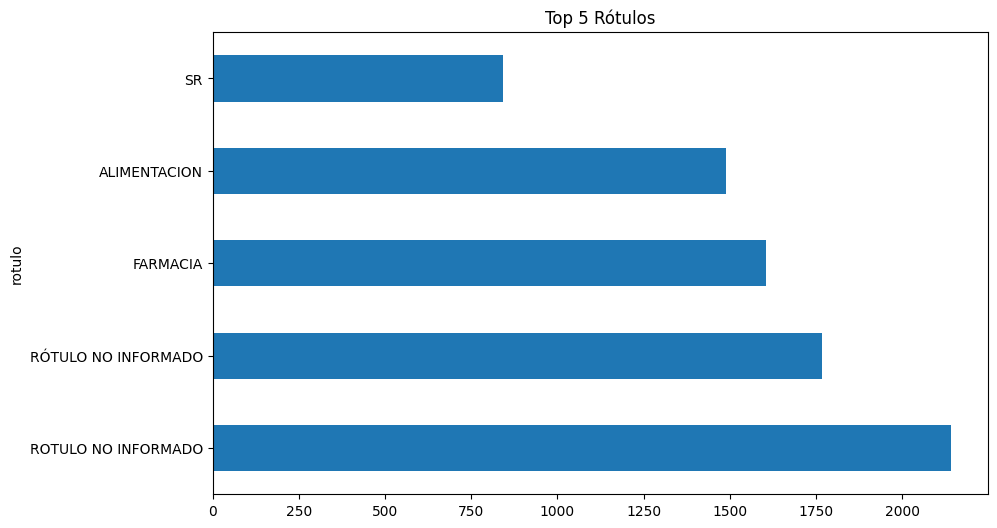

In [26]:
df.value_counts("rotulo").head().plot(kind='barh', figsize=(10, 6), title="Top 5 Rótulos")

plt.show()

El estandar Unicode varios caracteres se pueden expresar de diversas formas. Por ejemplo, el carácter [U+00D1 (Letra N MAYÚSCULA con tilde)](https://www.compart.com/en/unicode/U+00D1) también se puede expresar con la secuencia [U+004E (Letra N MAYÚSCULA)](https://www.compart.com/en/unicode/U+004E) [U+0303 (Tilde combinable)](https://www.compart.com/en/unicode/U+0303).

El carácter unicode [U+0301 representa el acento agudo combinable](https://www.compart.com/en/unicode/U+0301).

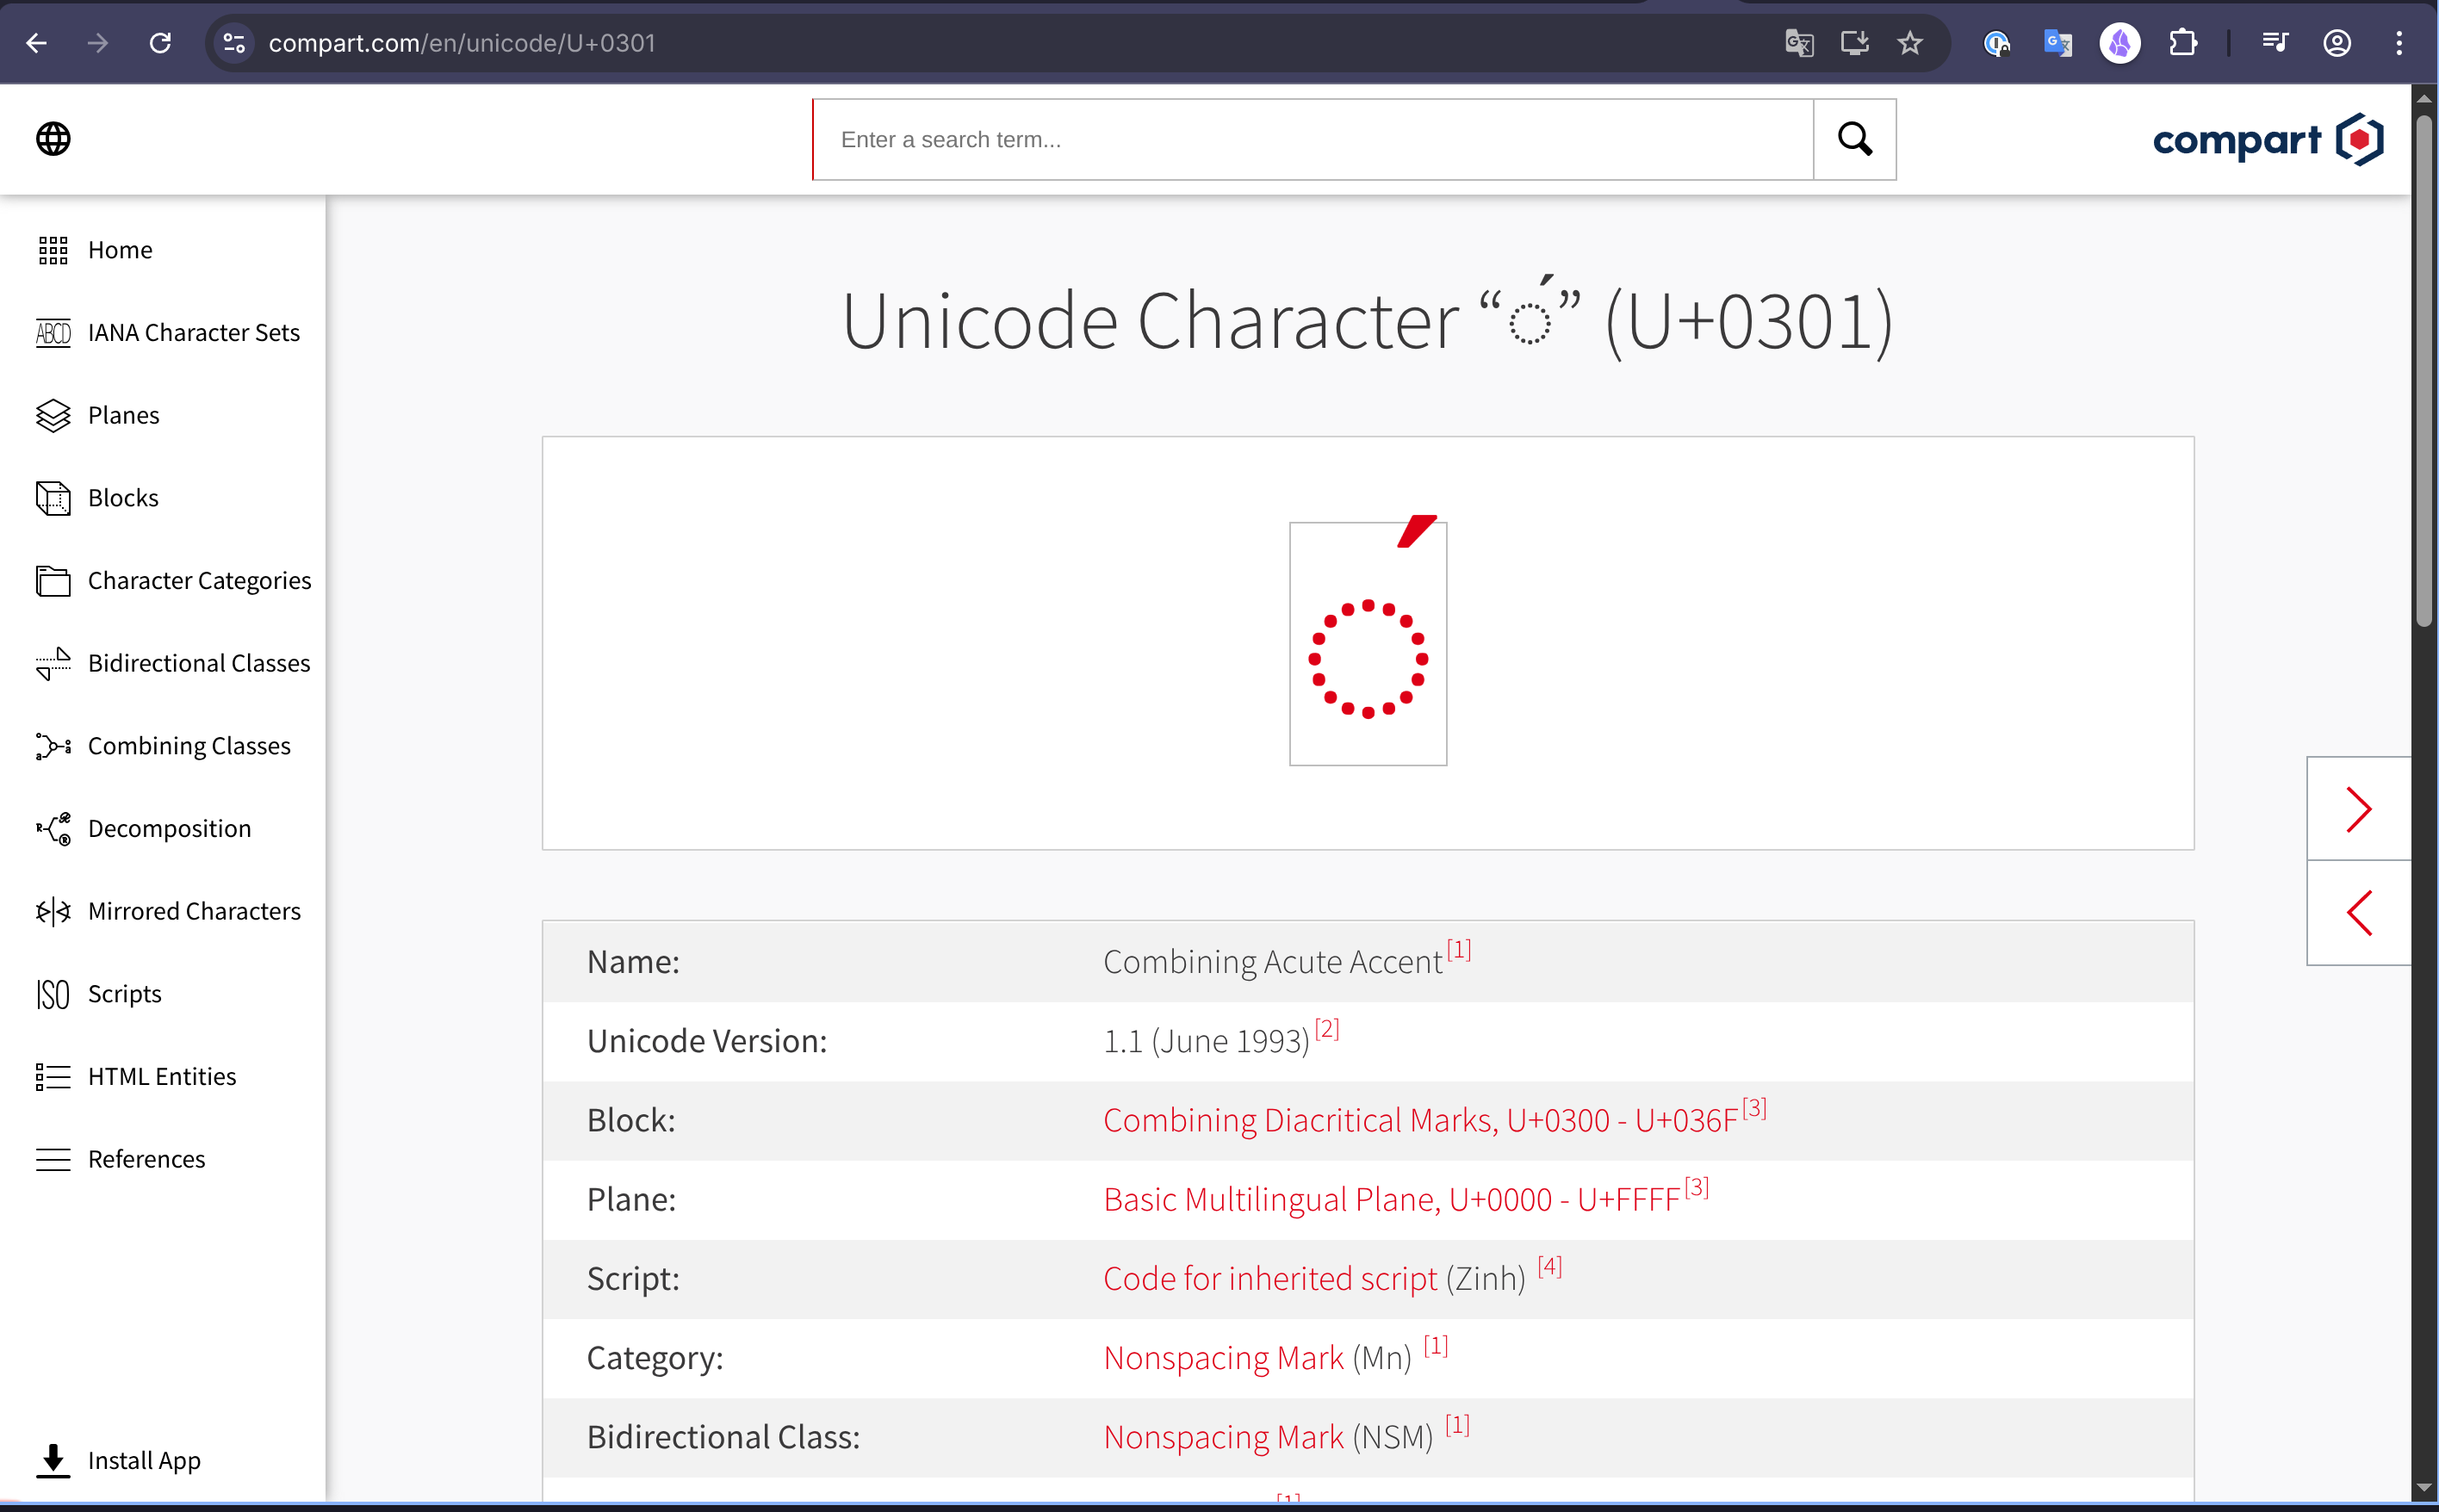

In [27]:
# Para normalizar las cadenas de texto eliminando los acentos, primero normalizamos a la forma compuesta y luego filtramos
# el caracter U+0301

string = "RÓTULO NO INFORMADO"

print("Formas normalizada de Unicode")
print("============================")
print('Cadena normalizada "NKFC":', ascii(unicodedata.normalize("NFKC", string)))
print('Cadena normalizada "NFC":', ascii(unicodedata.normalize("NFC", string)))
print('Cadena normalizada "NFKD":', ascii(unicodedata.normalize("NFKD", string)))
print('Cadena normalizada "NFD":', ascii(unicodedata.normalize("NFD", string)))

print("\nNormalización de los acentos")
print("============================")
print("Cadena sin acentos:", "".join(c for c in unicodedata.normalize("NFKD", string) if c != "\u0301"))

Formas normalizada de Unicode
Cadena normalizada "NKFC": 'R\xd3TULO NO INFORMADO'
Cadena normalizada "NFC": 'R\xd3TULO NO INFORMADO'
Cadena normalizada "NFKD": 'RO\u0301TULO NO INFORMADO'
Cadena normalizada "NFD": 'RO\u0301TULO NO INFORMADO'

Normalización de los acentos
Cadena sin acentos: ROTULO NO INFORMADO


In [28]:
def normalize_str(string):
    """
    Función para normalizar las cadenas de texto:
        sin espacios iniciales/finales, mayúsculas, suprimir tildes
    """
    if pd.isna(string):
        return pd.NA

    string = string.strip()
    string = string.upper()
    string = "".join(c for c in unicodedata.normalize("NFKD", string) if c != "\u0301")

    # Si la cadena de texto está vacía, retorna nulo
    if not string:
        return pd.NA

    return string


print("Ejemplos de normalización de cadenas de texto:")
print("==========================================\n")
for col in "ROTULO NO INFORMADO", "RÓTULO NO INFORMADO", "CENTRO              ", "\n   \t":
    print(f"{col!r:^22} -> {normalize_str(col)!r}")

Ejemplos de normalización de cadenas de texto:

'ROTULO NO INFORMADO'  -> 'ROTULO NO INFORMADO'
'RÓTULO NO INFORMADO'  -> 'ROTULO NO INFORMADO'
'CENTRO              ' -> 'CENTRO'
      '\n   \t'        -> <NA>


In [29]:
def normalize_str_cols(data):
    df = data.copy()
    for col in df.columns:
        if df[col].dtype in ('object', 'string'):
            print(f"Normalizando columna: {col}, tipo: {df[col].dtype}")
            df[col] = df[col].apply(normalize_str)
    return df

In [30]:
clean_steps.append({
    "dataset": "licencias",
    "columna": "columnas de tipo texto",
    "ejemplo_valor": repr(df["desc_distrito_local"].sample(1, random_state=42).item()),
    "impacto": "alto",
    "accion_sugerida": "normalizar textos: sin espacios iniciales/finales, mayúsculas, suprimir tildes",
    "funcion": "\n".join([
        inspect.getsource(normalize_str),
        inspect.getsource(normalize_str_cols)
    ])
})

#### Convertir campos de fecha y hora


Convertir `fecha_dec_Lic` en formato fecha.

In [31]:
clean_steps.append({
    "dataset": "licencias",
    "columna": "fecha_dec_lic",
    "ejemplo_valor": df["fecha_dec_lic"].sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "convertir campo fecha a formato fecha válido",
    "funcion": "pd.to_datetime"
})

#### Normalizar coordenadas espaciales

Unificaremos las coordenadas en un único campo que tome las `coordenada_x/y_local` si es **Puerta de Calle** y `coordenada_x/y_agrupacion` si es **Agrupado**, nulo en cualquier otro caso.

Las coordenadas del dataset aparecen en formato **UTM** *(Sistema de referencia:
Hasta el 15 de septiembre de 2017 ED-50, a partir de esa fecha
ETRS8)*. Vamos a suponer **ETRS8** ya que no tenemos el dato de cuando se recogen las coordenadas de los locales, podemos utilizar una [calculadora geodesica](https://www.ign.es/web/calculadora-geodesica) para convertir las coodenadas as longitud, latitud y visualizar la posición.

In [32]:
df[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE")][["desc_distrito_local", "desc_barrio_local", "clase_vial_acceso", "desc_vial_acceso", "desc_vial_edificio", "rotulo", "coordenada_x_local", "coordenada_y_local"]]

,desc_distrito_local,desc_barrio_local,clase_vial_acceso,desc_vial_acceso,desc_vial_edificio,rotulo,coordenada_x_local,coordenada_y_local
6719,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO ...,LOZANO ...,SANFERBIKE,443072.56,4471928.5
24888,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO ...,LOZANO ...,SANFERBIKE,443072.56,4471928.5


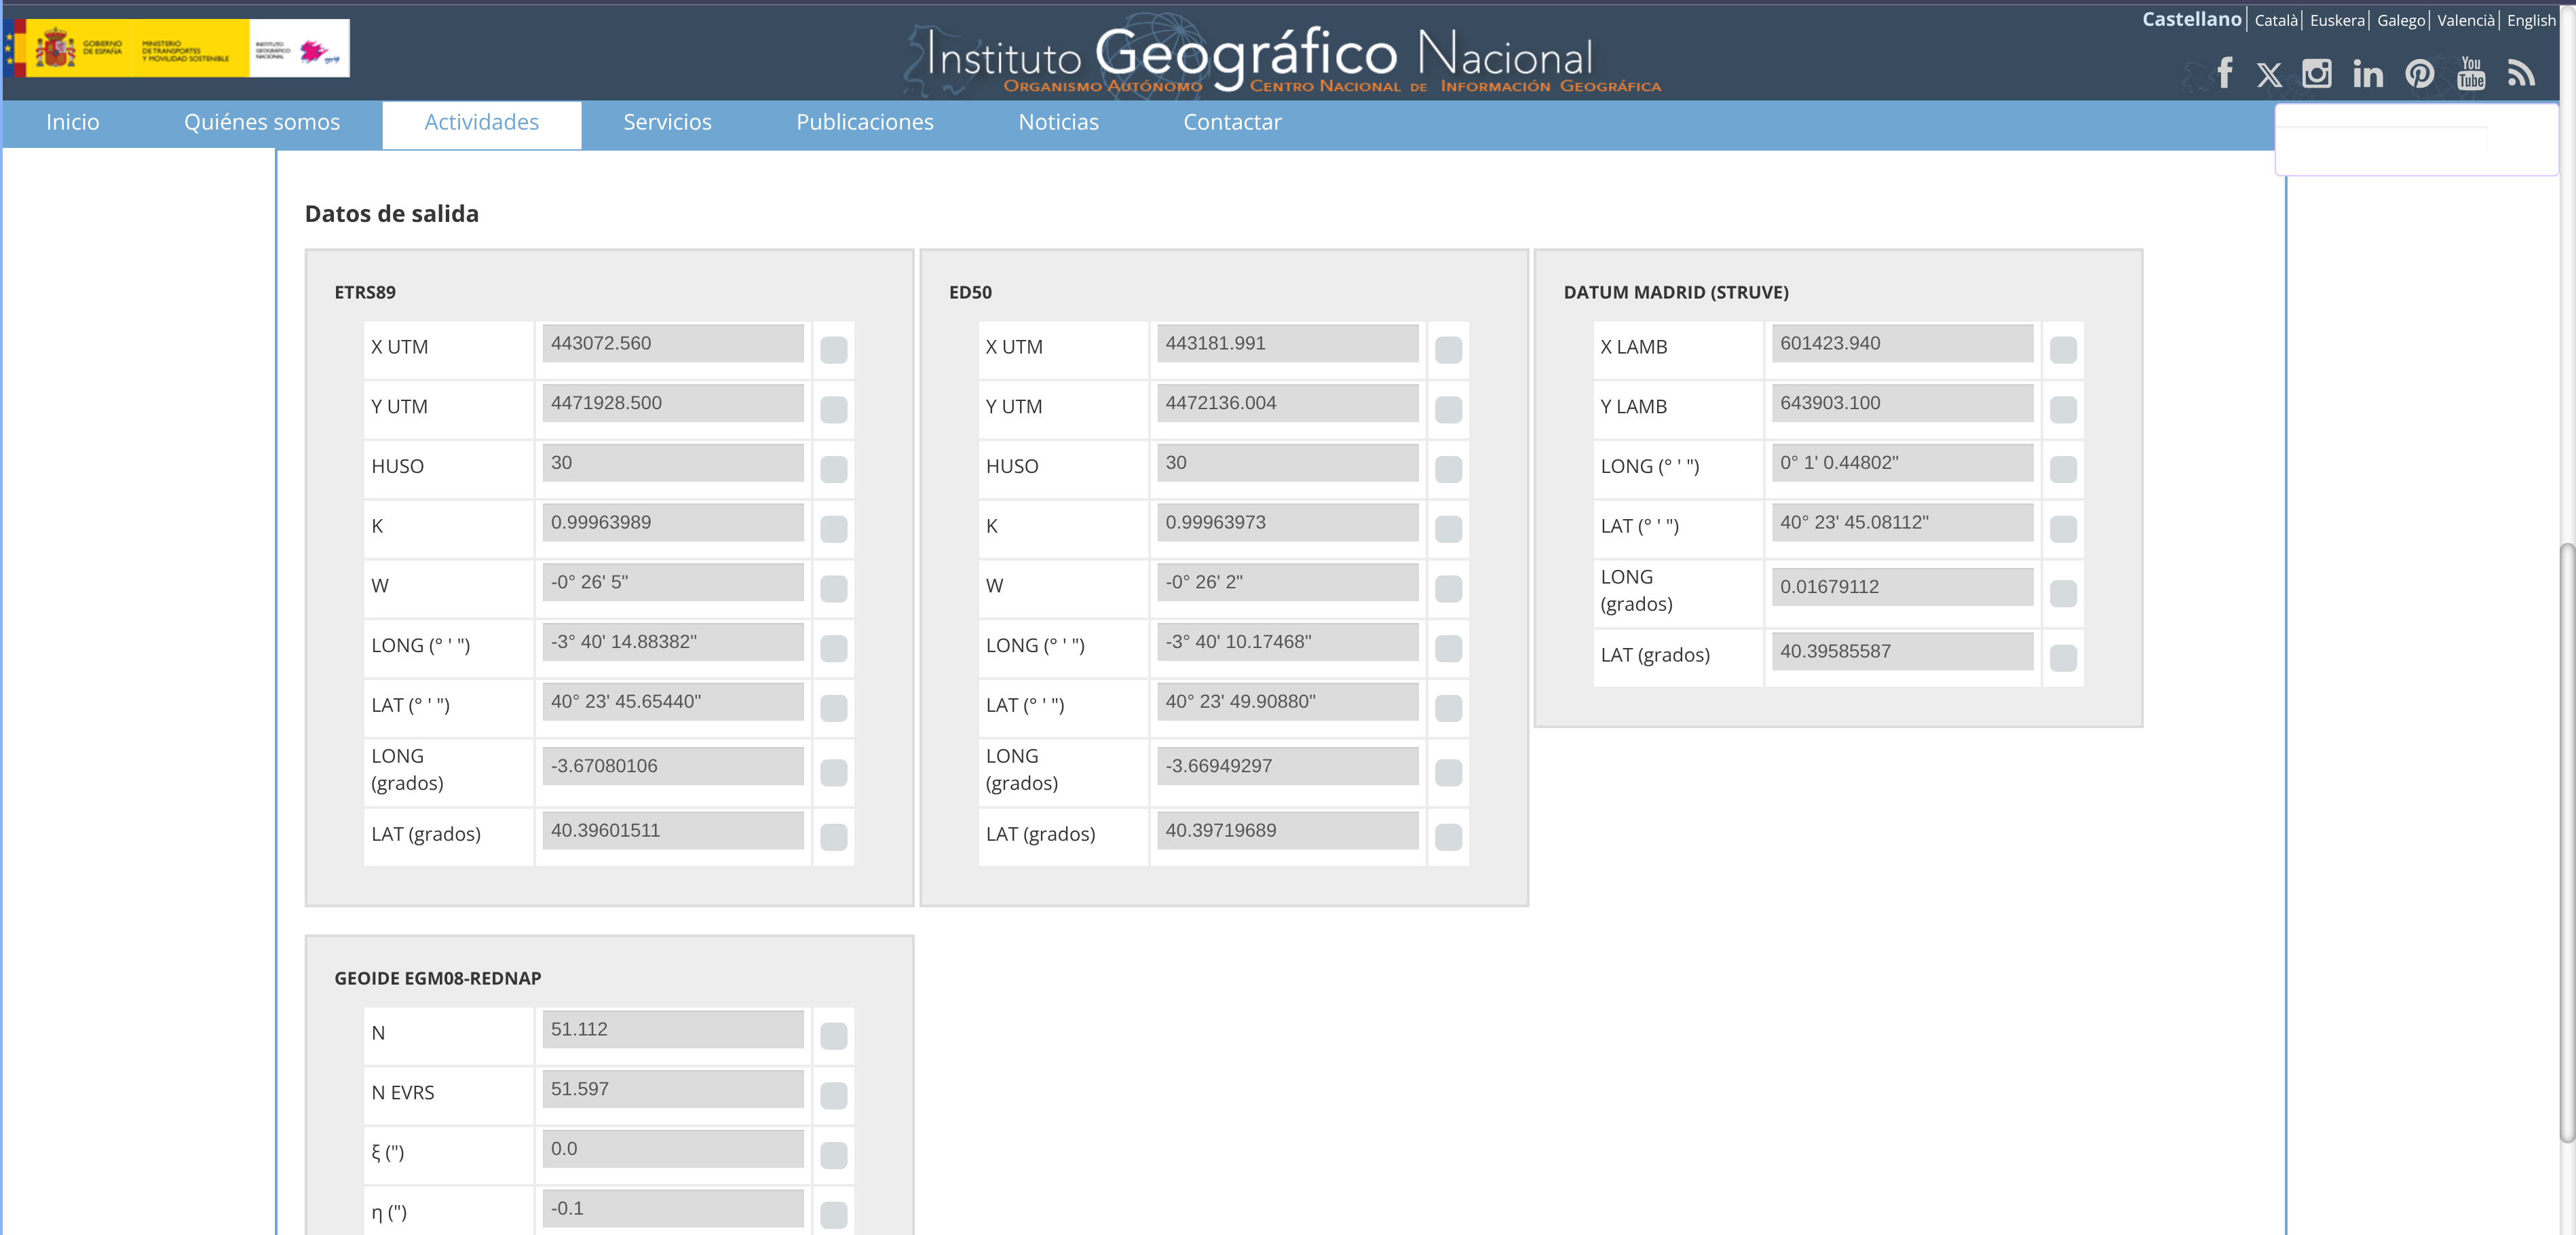

**Comprobamos** que las coordenadas de latitud y longitud que obtenemos con la calculadora geodésica son correctas: https://www.google.com/maps/place/40%C2%B023'45.7%22N+3%C2%B040'14.9%22W/@40.3958793,-3.6708874,20.63z/data=!4m4!3m3!8m2!3d40.3960278!4d-3.6708056?entry=ttu&g_ep=EgoyMDI2MDUyMC4wIKXMDSoASAFQAw%3D%3D


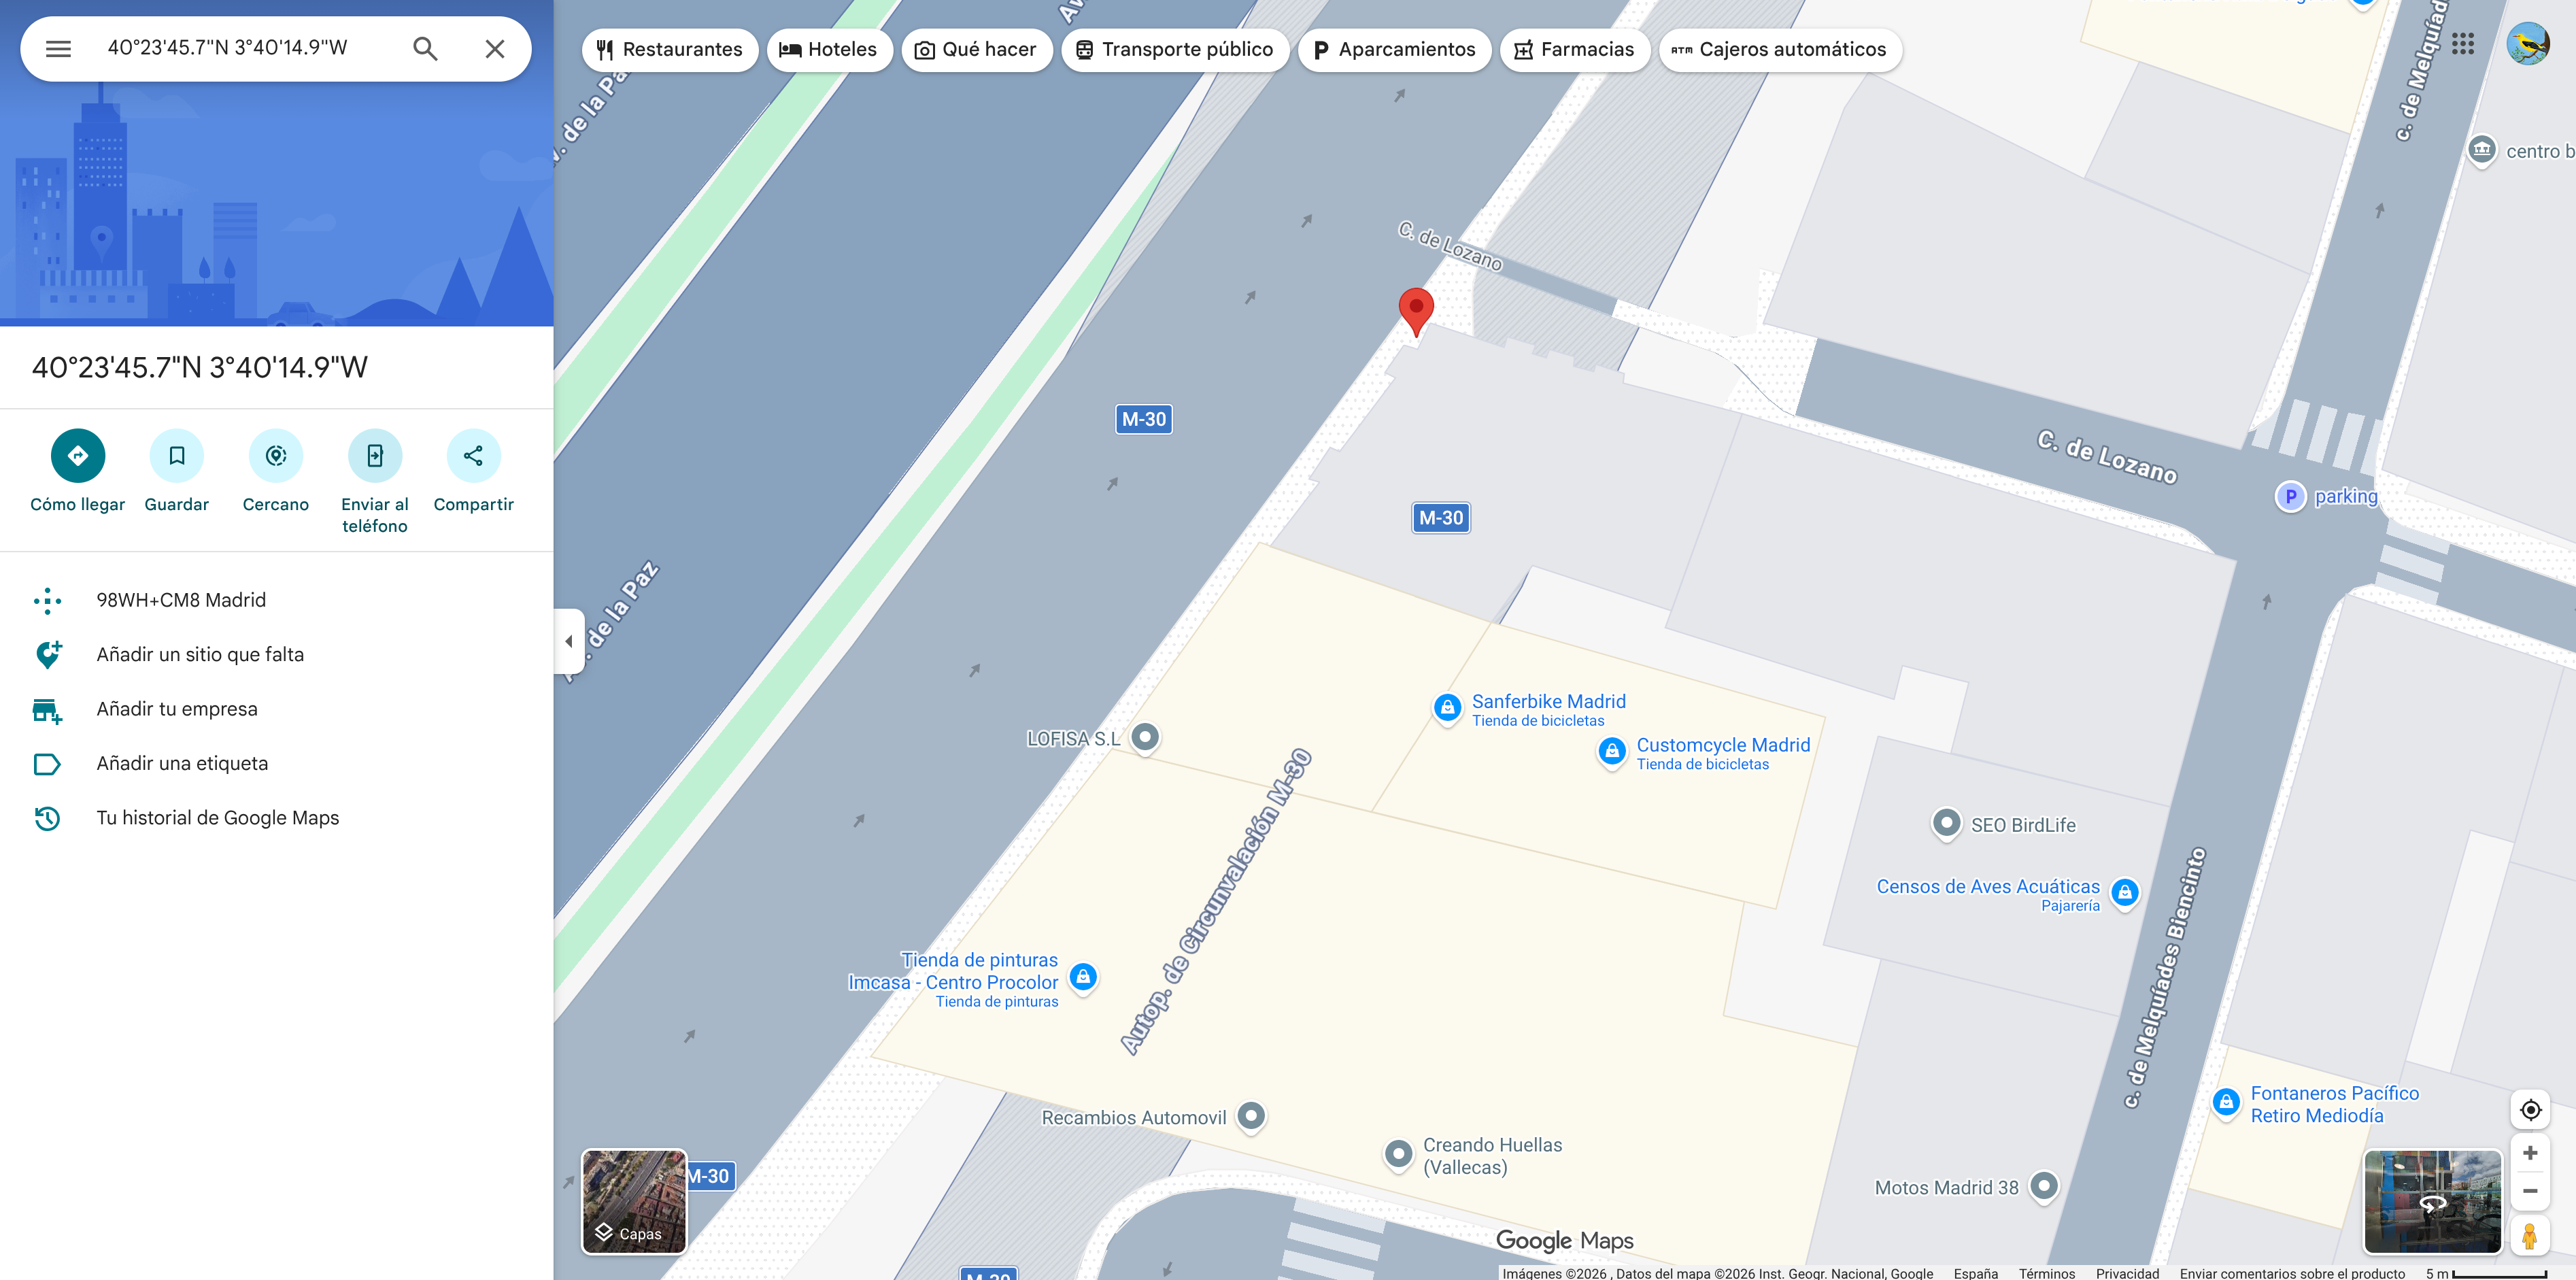

Utilizaremos las librería `pyproj` para convertir las cooredanadas a **latitud, longitud**.

In [33]:
df[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE")][["desc_distrito_local", "desc_barrio_local", "clase_vial_acceso", "desc_vial_acceso", "desc_vial_edificio", "rotulo", "coordenada_x_local", "coordenada_y_local"]]

,desc_distrito_local,desc_barrio_local,clase_vial_acceso,desc_vial_acceso,desc_vial_edificio,rotulo,coordenada_x_local,coordenada_y_local
6719,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO ...,LOZANO ...,SANFERBIKE,443072.56,4471928.5
24888,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO ...,LOZANO ...,SANFERBIKE,443072.56,4471928.5


In [34]:
df[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE")].iloc[0][["coordenada_x_local", "coordenada_y_local"]].to_list()

[np.float64(443072.56), np.float64(4471928.5)]

In [35]:
coords = df[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE")].iloc[0][["coordenada_x_local", "coordenada_y_local"]].to_list()

# Convertir ETRS89 / UTM 30N -> WGS84 lon/lat
# Ver: https://epsg.io/25830
# Ver: https://epsg.io/4326
id_tipo_acceso_local = Transformer.from_crs(
    "EPSG:25830",
    "EPSG:4326",
    always_xy=True
)

lon, lat = id_tipo_acceso_local.transform(coords[0], coords[1])

In [36]:
def visualizar_coordenadas(lat, lon):
    """
    Función para visualizar las coordenadas en un mapa.
    """
    # Crear mapa centrado en el punto
    map = folium.Map(
        location=[lat, lon],
        zoom_start=20,
        tiles="OpenStreetMap"
    )

    # Añadir punto
    folium.Marker(
        location=[lat, lon],
        popup="Local",
        tooltip="Local"
    ).add_to(map)

    # Añadir círculo de 10 metros alrededor
    folium.Circle(
        location=[lat, lon],
        radius=10,
        color="red",
        fill=False,
        popup="Radio 10 m"
    ).add_to(map)

    return map

visualizar_coordenadas(lat, lon)

In [37]:
def unificar_coordenadas(data):
    """
    Función para unificar las coordenadas espaciales en un único campo y convertir a latitud, longitud.
    """
    df = data.copy()
    coordenada_x = np.select(
        [
            df["id_tipo_acceso_local"].eq(1),
            df["id_tipo_acceso_local"].eq(0)
        ],
        [
            df["coordenada_x_local"],
            df["coordenada_x_agrupacion"]
        ],
        default=np.nan
    )
    coordenada_y = np.select(
        [
            df["id_tipo_acceso_local"].eq(1),
            df["id_tipo_acceso_local"].eq(0)
        ],
        [
            df["coordenada_y_local"],
            df["coordenada_y_agrupacion"]
        ],
        default=np.nan
    )

    # Convertir a latitud, longitud
    df["lat"] = np.nan
    df["lon"] = np.nan

    mask_coord = ~np.isnan(coordenada_x) & ~np.isnan(coordenada_y)

    etrs89_to_wgs84 = Transformer.from_crs(
        "EPSG:25830",  # ETRS89 / UTM 30N
        "EPSG:4326",
        always_xy=True
    )

    lon, lat = etrs89_to_wgs84.transform(
        coordenada_x[mask_coord],
        coordenada_y[mask_coord]
    )

    df.loc[mask_coord, "lon"] = lon
    df.loc[mask_coord, "lat"] = lat

    df = df.drop(columns=["coordenada_x_local", "coordenada_y_local", "coordenada_x_agrupacion", "coordenada_y_agrupacion"])
    return df

In [39]:
for axis in ["x", "y"]:
    clean_steps.append({
        "dataset": "licencias",
        "columna": f"coordenada_{axis}_local + coordenada_{axis}_agrupacion = coordenada_{axis}",
        "ejemplo_valor": pd.NA,
        "impacto": "medio",
        "accion_sugerida": """unificar coordenadas, cuando id_tipo_acceso_local=1 se usa las de _local
            cuando id_tipo_acceso_local=0 se usa _agrupacion y convertir a latitud, longitud""",
        "funcion": inspect.getsource(unificar_coordenadas)
    })

### Aplicación de transformaciones

In [40]:
is_licencias = lambda row: row.get("dataset", "") == "licencias"

clean_df = pd.DataFrame(filter(is_licencias, clean_steps))

clean_df

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
0,licencias,todas,desc_situacion_local,alto,normalizar el nombre de las columnas,"def normalize_column_name(col):\n """"""\n ..."
1,licencias,fecha_dec_lic,01/01/1900,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,licencias,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,licencias,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,licencias,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,licencias,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,licencias,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
7,licencias,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
8,licencias,id_tipo_situacion_licencia,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
9,licencias,fecha_dec_lic,01/01/1900,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


#### Convertir valores centinela

In [41]:
clean_df[clean_df['accion_sugerida'].str.contains("nulos")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
1,licencias,fecha_dec_lic,01/01/1900,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,licencias,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,licencias,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,licencias,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,licencias,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,licencias,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
7,licencias,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
8,licencias,id_tipo_situacion_licencia,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
9,licencias,fecha_dec_lic,01/01/1900,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
10,licencias,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


In [42]:
# Convertir valores centinela a nulos
columns = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "columna"].to_list()
sentinels = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "ejemplo_valor"].to_list()

df = df.pipe(sentinel_to_null, columns, sentinels)

In [43]:
# Valores nulos tras la conversión

missing_data(df[columns])

,fecha_dec_lic,coordenada_x_local,coordenada_y_local,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,id_tipo_agrup,id_tipo_situacion_licencia,fecha_dec_lic,coordenada_x_local,coordenada_y_local,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,id_tipo_agrup,id_tipo_situacion_licencia
Total,27662,5234,5234,142161,142161,141556,141556,5984,27662,5234,5234,142161,142161,141556,141556,5984
Porcentaje,18.339974,3.470155,3.470155,94.253095,94.253095,93.851978,93.851978,3.967407,18.339974,3.470155,3.470155,94.253095,94.253095,93.851978,93.851978,3.967407
Tipos,object,float64,float64,float64,float64,Int64,Int64,Int64,object,float64,float64,float64,float64,Int64,Int64,Int64


#### Eliminar columnas

In [44]:
clean_df[clean_df['accion_sugerida'] == "eliminar"]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
17,licencias,fx_carga,2023-12-08 07:00:34.15,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
18,licencias,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
19,licencias,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."


In [45]:
columns=clean_df.loc[clean_df['accion_sugerida'] == "eliminar", "columna"]
df = df.drop(columns=columns)

df.columns

Index(['id_local', 'id_distrito_local', 'desc_distrito_local',
       'id_barrio_local', 'desc_barrio_local', 'cod_barrio_local',
       'id_seccion_censal_local', 'desc_seccion_censal_local',
       'coordenada_x_local', 'coordenada_y_local', 'id_tipo_acceso_local',
       'desc_tipo_acceso_local', 'id_situacion_local', 'desc_situacion_local',
       'id_ndp_edificio', 'id_clase_ndp_edificio', 'id_vial_edificio',
       'clase_vial_edificio', 'desc_vial_edificio', 'nom_edificio',
       'num_edificio', 'cal_edificio', 'secuencial_local_pc', 'id_ndp_acceso',
       'id_clase_ndp_acceso', 'id_vial_acceso', 'clase_vial_acceso',
       'desc_vial_acceso', 'nom_acceso', 'num_acceso', 'cal_acceso',
       'coordenada_x_agrupacion', 'coordenada_y_agrupacion', 'id_agrupacion',
       'nombre_agrupacion', 'id_tipo_agrup', 'desc_tipo_agrup',
       'id_planta_agrupado', 'id_local_agrupado', 'rotulo', 'ref_licencia',
       'id_tipo_licencia', 'desc_tipo_licencia', 'id_tipo_situacion_licencia',


#### Normalizar los campos de texto


In [46]:
df = df.pipe(normalize_str_cols)

Normalizando columna: desc_distrito_local, tipo: object
Normalizando columna: desc_barrio_local, tipo: object
Normalizando columna: desc_seccion_censal_local, tipo: string
Normalizando columna: desc_tipo_acceso_local, tipo: object
Normalizando columna: desc_situacion_local, tipo: object
Normalizando columna: clase_vial_edificio, tipo: object
Normalizando columna: desc_vial_edificio, tipo: object
Normalizando columna: nom_edificio, tipo: object
Normalizando columna: cal_edificio, tipo: object
Normalizando columna: clase_vial_acceso, tipo: object
Normalizando columna: desc_vial_acceso, tipo: object
Normalizando columna: nom_acceso, tipo: object
Normalizando columna: cal_acceso, tipo: object
Normalizando columna: nombre_agrupacion, tipo: object
Normalizando columna: desc_tipo_agrup, tipo: object
Normalizando columna: id_planta_agrupado, tipo: object
Normalizando columna: id_local_agrupado, tipo: object
Normalizando columna: rotulo, tipo: object
Normalizando columna: ref_licencia, tipo: ob

In [47]:
df[[col for col in df.columns if df[col].dtype in ('object', 'string')]].head()

,desc_distrito_local,desc_barrio_local,desc_seccion_censal_local,desc_tipo_acceso_local,desc_situacion_local,clase_vial_edificio,desc_vial_edificio,nom_edificio,cal_edificio,clase_vial_acceso,desc_vial_acceso,nom_acceso,cal_acceso,nombre_agrupacion,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,desc_tipo_licencia,desc_tipo_situacion_licencia,fecha_dec_lic
0,CHAMBERI,ALMAGRO,92,PUERTA CALLE,ABIERTO,CALLE,ZURBANO,NUM,<NA>,CALLE,ZURBANO,NUM,<NA>,SIN AGRUPACION,SIN AGRUPACION,PB,01,CAFE PLATINA,350/2023/26343,TRANSMISION DE LICENCIA URBANISTICA,TRANSMISION DE LICENCIA CONCEDIDA,<NA>
1,FUENCARRAL-EL PARDO,EL PILAR,78,PUERTA CALLE,ABIERTO,CALLE,GINZO DE LIMIA,NUM,<NA>,CALLE,GINZO DE LIMIA,NUM,<NA>,SIN AGRUPACION,SIN AGRUPACION,PB,02,CLINICA VETERINARIA GINZO DE LIMIA,108/2007/07166,LICENCIA URBANISTICA,CONCEDIDA,31/08/2009
2,FUENCARRAL-EL PARDO,VALVERDE,117,PUERTA CALLE,ABIERTO,CALLE,MANRESA,NUM,<NA>,CALLE,MANRESA,NUM,<NA>,SIN AGRUPACION,SIN AGRUPACION,PB,F,FARMACIA,500/2015/05608,DECLARACION RESPONSABLE,EN TRAMITACION,10/04/2015
3,PUENTE DE VALLECAS,NUMANCIA,177,PUERTA CALLE,ABIERTO,CALLE,VENANCIO MARTIN,NUM,<NA>,CALLE,VENANCIO MARTIN,NUM,<NA>,SIN AGRUPACION,SIN AGRUPACION,PB,B,FARMACIA,220/2011/13207,TRANSMISION DE LICENCIA URBANISTICA,EN TRAMITACION,15/11/2011
4,CHAMBERI,TRAFALGAR,67,PUERTA CALLE,ABIERTO,CALLE,ELOY GONZALO,NUM,<NA>,CALLE,SANTISIMA TRINIDAD,NUM,<NA>,SIN AGRUPACION,SIN AGRUPACION,PB,03,BAZAR MATEY,107/2004/07541,LICENCIA URBANISTICA,CONCEDIDA,14/06/2005


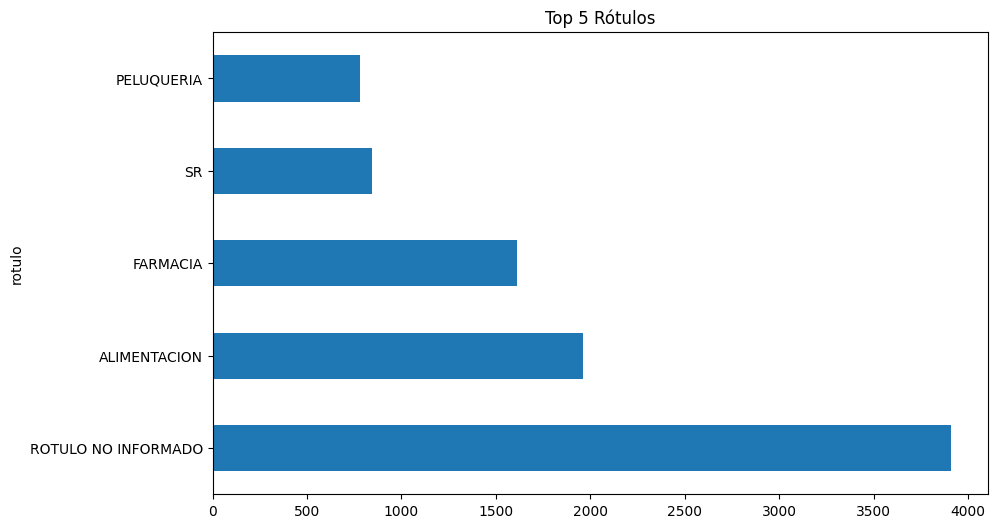

In [48]:
# Comprobamos que ya no existen dos categororías diferentes de "ROTULO NO INFORMADO"

df.value_counts("rotulo").head().plot(kind='barh', figsize=(10, 6), title="Top 5 Rótulos")

plt.show()

#### Convertir campos de fecha y hora

In [49]:
clean_df[clean_df['accion_sugerida'].str.contains(r"fecha")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
21,licencias,fecha_dec_lic,09/10/2001,alto,convertir campo fecha a formato fecha válido,pd.to_datetime


In [50]:
df["fecha_dec_lic"] = pd.to_datetime(df["fecha_dec_lic"], errors="coerce", format="%d/%m/%Y")
df["fecha_dec_lic"]

,fecha_dec_lic
0,NaT
1,2009-08-31
2,2015-04-10
3,2011-11-15
4,2005-06-14
...,...
150824,2019-12-17
150825,2001-01-26
150826,NaT
150827,NaT


#### Normalizar coordenadas espaciales

In [51]:
df = df.pipe(unificar_coordenadas)

df.head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,fecha_dec_lic,lat,lon
0,270366725,7,CHAMBERI,704,ALMAGRO,4,7092,92,1,PUERTA CALLE,1,ABIERTO,11041540,1,807000,CALLE,ZURBANO,NUM,69,<NA>,10,11041540,1,807000,CALLE,ZURBANO,NUM,69,<NA>,<NA>,SIN AGRUPACION,<NA>,SIN AGRUPACION,PB,01,CAFE PLATINA,350/2023/26343,4,TRANSMISION DE LICENCIA URBANISTICA,5,TRANSMISION DE LICENCIA CONCEDIDA,NaT,40.437037,-3.693115
1,270433440,8,FUENCARRAL-EL PARDO,804,EL PILAR,4,8078,78,1,PUERTA CALLE,1,ABIERTO,11046624,1,337350,CALLE,GINZO DE LIMIA,NUM,33,<NA>,20,11046624,1,337350,CALLE,GINZO DE LIMIA,NUM,33,<NA>,<NA>,SIN AGRUPACION,<NA>,SIN AGRUPACION,PB,02,CLINICA VETERINARIA GINZO DE LIMIA,108/2007/07166,2,LICENCIA URBANISTICA,2,CONCEDIDA,2009-08-31,40.478231,-3.704227
2,270433462,8,FUENCARRAL-EL PARDO,806,VALVERDE,6,8117,117,1,PUERTA CALLE,1,ABIERTO,11047985,1,459700,CALLE,MANRESA,NUM,44,<NA>,20,11047985,1,459700,CALLE,MANRESA,NUM,44,<NA>,<NA>,SIN AGRUPACION,<NA>,SIN AGRUPACION,PB,F,FARMACIA,500/2015/05608,1,DECLARACION RESPONSABLE,1,EN TRAMITACION,2015-04-10,40.492191,-3.692962
3,270433466,13,PUENTE DE VALLECAS,1306,NUMANCIA,6,13177,177,1,PUERTA CALLE,1,ABIERTO,11099179,1,773600,CALLE,VENANCIO MARTIN,NUM,45,<NA>,20,11099179,1,773600,CALLE,VENANCIO MARTIN,NUM,45,<NA>,<NA>,SIN AGRUPACION,<NA>,SIN AGRUPACION,PB,B,FARMACIA,220/2011/13207,4,TRANSMISION DE LICENCIA URBANISTICA,1,EN TRAMITACION,2011-11-15,40.396837,-3.657859
4,270433476,7,CHAMBERI,703,TRAFALGAR,3,7067,67,1,PUERTA CALLE,1,ABIERTO,11040448,1,261400,CALLE,ELOY GONZALO,NUM,27,<NA>,40,11040460,1,701700,CALLE,SANTISIMA TRINIDAD,NUM,1,<NA>,<NA>,SIN AGRUPACION,<NA>,SIN AGRUPACION,PB,03,BAZAR MATEY,107/2004/07541,2,LICENCIA URBANISTICA,2,CONCEDIDA,2005-06-14,40.434849,-3.700438


In [52]:
# Check de las coordenadas transformadas

df[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE")][["desc_distrito_local", "desc_barrio_local", "clase_vial_acceso", "desc_vial_acceso", "desc_vial_edificio", "rotulo", "fecha_dec_lic", "lon", "lat"]]

,desc_distrito_local,desc_barrio_local,clase_vial_acceso,desc_vial_acceso,desc_vial_edificio,rotulo,fecha_dec_lic,lon,lat
6719,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO,LOZANO,SANFERBIKE,NaT,-3.670801,40.396015
24888,PUENTE DE VALLECAS,SAN DIEGO,CALLE,LOZANO,LOZANO,SANFERBIKE,2015-02-05,-3.670801,40.396015


In [53]:
lon, lat = df.loc[(df['id_tipo_acceso_local'] == 1) & (df['rotulo'] == "SANFERBIKE"), ["lon", "lat"]].iloc[0].to_list()

visualizar_coordenadas(lat, lon)

### Guardar el conjunto de datos resultante

In [54]:
df.to_csv(DATA_DIR / 'licencias.csv', index=False)

##  Terrazas

### Descripción del fichero

 [Contenido y estructura de los ficheros de terrazas](https://datos.madrid.es/dataset/200085-0-censo-locales/resource/200085-10-censo-locales).

#### Categoría: identificación de terraza y local

| Campo | Descripción |
| :--- | :--- |
| `id_terraza` | Código único que identifica la terraza. |
| `id_local` | Código numérico único del local asociado. |
| `rotulo` | Nombre comercial del establecimiento. |


#### Categoría: identificación y localización del local

| Campo | Descripción |
| :--- | :--- |
| `id_distrito_local` | Código numérico del distrito. |
| `desc_distrito_local` | Nombre del distrito municipal. |
| `id_barrio_local` | Código numérico del barrio (incluye el distrito). |
| `desc_barrio_local` | Nombre del barrio municipal. |
| `Cod_postal` | Código postal del local. |


#### Categoría: estado y acceso del local

| Campo | Descripción |
| :--- | :--- |
| `id_tipo_acceso_local` | Código del tipo de acceso. *(Ver Tabla A)* |
| `desc_tipo_acceso_local` | Literal del tipo de acceso. *(Ver Tabla A)* |
| `id_situacion_local` | Código de la situación de actividad actual. *(Ver Tabla B)* |
| `desc_situacion_local` | Literal de la situación del local. *(Ver Tabla B)* |


#### Categoría: dirección del edificio y ubicación de terraza

> *Nota: El dataset contiene dos direcciones: la del edificio del local, y la ubicación exacta de la terraza.*

**Bloque A: Dirección del Local (Edificio y Puerta)**

| Campo | Descripción |
| :--- | :--- |
| `id_ndp_edificio` | Código numérico oficial de la dirección del edificio. |
| `Id_clase_ndp_edificio`| `1` (Oficial/Normalizada) o `9` (No normalizada). |
| `id_vial_edificio` | Código de clase + nombre de la vía del edificio. |
| `clase_vial_edificio` | Tipo de vía (Calle, Avenida, Plaza…). |
| `desc_vial_edificio` | Nombre de la vía oficial. |
| `nom_edificio` a `cal_edificio` | Detalles de numeración (Tipo, Número, Calificador). |
| `secuencial_local_PC` | Orden secuencial (saltos decenales) del local en la fachada. |
| `Escalera` | Escalera del edificio. *(Solo aplica a accesos tipo "Interior")*. |
| `id_planta_agrupado` | Planta en la agrupación. *(Solo para acceso "Agrupado")*. |
| `id_local_agrupado` | Puerta en la agrupación. *(Solo para acceso "Agrupado")*. |
| `coordenadas x-y_local` | UTM del local "Puerta de Calle". *(Inválido para otros tipos)*. |
| `coordenadas x-y de la agrupación`| UTM de la agrupación comercial. |

**Bloque B: Dirección y Emplazamiento Físico de la Terraza**
*(Nota: Estos campos vienen en mayúsculas en el origen)*

| Campo | Descripción |
| :--- | :--- |
| `id_ndp_terraza` | Código NDP de la dirección más cercana a la terraza física. |
| `id_clase_ndp_terraza` | `1` (Oficial/Normalizada) o `9` (No normalizada). |
| `ID_VIAL` | Código numérico de la vía de la terraza. |
| `DESC_CLASE` | Tipo de vía de la terraza. |
| `DESC_NOMBRE` | Nombre oficial de la vía de la terraza. |
| `NOM_NUM` a `CAL_NUM` | Numeración de la ubicación de la terraza. |
| `desc_ubicacion_terraza` | Emplazamiento: Acera, Plaza peatonal, Parcela privada, Bulevar, Calle peatonal, Calle sin salida, Plaza con bandas rodadas, Otros. |


#### Categoría: campos propios de terrazas

| Campo | Descripción |
| :--- | :--- |
| `id_periodo_terraza` | `1` (Anual) o `2` (Estacional). |
| `desc_periodo_terraza` | Literal: 'Anual' o 'Estacional'. |
| `id_situacion_terraza` | `1` (Abierta) o `8` (Suspensión temporal). |
| `desc_situacion_terraza` | Literal: 'Abierta' o 'Suspensión temporal'. |
| `Fecha_confir_ult_decreto_resol` | Fecha de resolución (Renovación, Cambio titular...). Formato `DD/MM/AAAA`. |
| `Superficie_es` | m² ocupados en periodo **estacional** (verano). |
| `Superficie_ra` | m² ocupados el **resto del año** (invierno/anual). |


#### Categoría: horarios autorizados de terrazas
*Formato:* `hh:mm:ss`. Se dividen por periodo (`es` = Estacional, `ra` = Resto del año) y por días (`LJ` = Dom a Jueves, `VS` = Vie, Sab y Vísperas).

| Días de la semana | Inicio / Fin | Periodo Estacional (`-es`) | Resto del Año (`-ra`) |
| :--- | :--- | :--- | :--- |
| **Dom a Jue (`LJ`)** | Inicio | `hora_ini_LJ-es` | `hora_ini_LJ-ra` |
| | Fin | `hora_fin_LJ-es` | `hora_fin_LJ-ra` |
| **Vie, Sab, Visp (`VS`)** | Inicio | `hora_ini_VS-es` | `hora_ini_VS-ra` |
| | Fin | `hora_fin_VS-es` | `hora_fin_VS-ra` |


#### Categoría: equipamiento y mobiliario de terrazas

| Tipo de Mobiliario | Periodo Estacional (`_es`) | Resto del Año (`_ra`) |
| :--- | :--- | :--- |
| **Mesas principales**| `mesas_es` | `mesas_ra` |
| **Mesas auxiliares** | `mesas_aux_es` | `mesas_aux_ra` |
| **Sillas** | `sillas_es` | `sillas_ra` |


#### Categoría: tablas de referencia

**Tabla A: Tipos de Acceso (`id_tipo_acceso_local`, `desc_tipo_acceso_local`)**

*   **0 - Agrupado:** Pertenece a una agrupación de locales.
*   **1 - Puerta de calle:** Acceso directo desde la vía pública.
*   **3 - Interior:** Acceso a través del portal del edificio.
*   **9 - Edificio.**
*   **12 - Puerta de calle asociado:** Varios titulares en un mismo local.


**Tabla B: Situación del Local (`id_situacion_local`, `desc_situacion_local`)**

*   **1 - Abierto**: Local activo en el que se desarrolla algún tipo de actividad económica.
*   **4 - Cerrado**: Local en el que en ese momento no se realiza ningún tipo de actividad.
*   **5 - Uso vivienda**: Locales puerta de calle que se han transformado en vivienda y se utlizan, exlcusivamente, como vivienda familiar.
*   **7 - Obras**: Locales en los que se está realizando una reforma.
*   **8 - Baja**: Locales desaparecidos.
*   **9 - Baja R - Reunificación**: Locales desaparecidos.

### Análisis exploratorio (EDA)

In [55]:
# Estas columnas traen valores nulos por lo que pandas las infiere como `float64` para que las siga tratando como entero
# pero permitiendo el uso de valores nulos tenemos que indicar que la parse como `Int64`
types = {
    "mesas_aux_ra": "Int64",
    "mesas_ra": "Int64",
    "sillas_ra": "Int64"
}

df = pd.read_csv('https://docs.google.com/uc?id=1pt6S7cwdpHLoXj3d0WqTlOhwdHopKik9', sep=';', decimal='.', encoding='utf-8', dtype=types)

# Normalizamos el nombre de las columnas
clean_steps.append({
    "dataset": "terrazas",
    "columna": "todas",
    "ejemplo_valor": df.columns.to_series().sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "normalizar el nombre de las columnas",
        "funcion": inspect.getsource(normalize_column_name)
})
df = df.rename(columns=normalize_column_name)

df.head()

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cod_postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_pc,escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,superficie_es,superficie_ra,fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,id_vial,desc_clase,desc_nombre,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_lj_es,hora_fin_lj_es,hora_ini_lj_ra,hora_fin_lj_ra,hora_ini_vs_es,hora_fin_vs_es,hora_ini_vs_ra,hora_fin_vs_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,cal_edificio,fx_carga,fx_datos_ini,fx_datos_fin
0,33,270403150,4,SALAMANCA,404,GUINDALERA,11018870,1,42500,AVENIDA,AMERICA ...,NUM,2,28028,442586.60,4476524.5,1,Puerta Calle,1,Abierto,30,NaN,PB,01,NaN,NaN,VIPS,1,Anual,1,Abierta,21.06,16.20,04/04/2014,11018870,1,42500,AVENIDA,AMERICA ...,NUM,2,,Acera,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,02:30:00,10:00:00,00:00:00,0,0,9,9,27,27,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
1,1168,80000291,8,FUENCARRAL-EL PARDO,806,VALVERDE,20057165,1,127,CALLE,ISABEL COLBRAND ...,NUM,10,28050,0.00,0.0,0,Agrupado,1,Abierto,0,NaN,PB,EX71,442993.62,4484849.5,RESTAURANTE DOMINÓ,1,Anual,1,Abierta,89.04,89.04,15/12/2014,20057165,1,127,CALLE,ISABEL COLBRAND ...,NUM,10,,Superficie en parcela privada,09:00:00,01:00:00,09:00:00,00:00:00,09:00:00,02:30:00,09:00:00,00:00:00,0,0,22,22,70,70,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
2,42,40002970,4,SALAMANCA,403,FUENTE DEL BERRO,11016907,1,88952587,CALLE,ALCALA ...,NUM,200,28028,443685.60,4475723.5,1,Puerta Calle,1,Abierto,20,NaN,PB,NaN,NaN,NaN,VIPS,1,Anual,1,Abierta,14.89,14.89,07/04/2014,11016907,1,88952587,CALLE,ALCALA ...,NUM,200,A,Acera,08:00:00,01:00:00,08:00:00,00:00:00,08:00:00,01:30:00,08:00:00,00:00:00,0,0,4,0,16,0,A,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
3,1176,40002488,4,SALAMANCA,406,CASTELLANA,11019901,1,411300,CALLE,JUAN BRAVO ...,NUM,25,28006,442284.60,4476020.5,1,Puerta Calle,1,Abierto,20,NaN,PB,NaN,NaN,NaN,SALITRE,1,Anual,1,Abierta,27.00,27.00,17/12/2014,11019901,1,411300,CALLE,JUAN BRAVO ...,NUM,25,,Bulevar,10:00:00,00:00:00,10:00:00,00:00:00,10:00:00,00:00:00,10:00:00,00:00:00,0,0,18,18,36,36,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
4,56,170000773,17,VILLAVERDE,1704,LOS ROSALES,11126803,1,786850,CALLE,VILLAJOYOSA ...,NUM,73,28041,441341.53,4467433.5,1,Puerta Calle,1,Abierto,10,NaN,PB,01,NaN,NaN,DONER KEBAB ARMENIA,2,Estacional,1,Abierta,12.96,NaN,14/04/2014,11126803,1,786850,CALLE,VILLAJOYOSA ...,NUM,73,,Acera,08:00:00,01:30:00,NaN,NaN,08:00:00,01:30:00,NaN,NaN,0,0,4,0,16,0,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6788 entries, 0 to 6787
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_terraza                      6788 non-null   int64  
 1   id_local                        6788 non-null   int64  
 2   id_distrito_local               6788 non-null   int64  
 3   desc_distrito_local             6788 non-null   object 
 4   id_barrio_local                 6788 non-null   int64  
 5   desc_barrio_local               6788 non-null   object 
 6   id_ndp_edificio                 6788 non-null   int64  
 7   id_clase_ndp_edificio           6788 non-null   int64  
 8   id_vial_edificio                6788 non-null   int64  
 9   clase_vial_edificio             6788 non-null   object 
 10  desc_vial_edificio              6788 non-null   object 
 11  nom_edificio                    6788 non-null   object 
 12  num_edificio                    67

In [57]:
missing_data(df)

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cod_postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_pc,escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,superficie_es,superficie_ra,fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,id_vial,desc_clase,desc_nombre,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_lj_es,hora_fin_lj_es,hora_ini_lj_ra,hora_fin_lj_ra,hora_ini_vs_es,hora_fin_vs_es,hora_ini_vs_ra,hora_fin_vs_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,cal_edificio,fx_carga,fx_datos_ini,fx_datos_fin
Total,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6665,4,1264,6683,6683,0,0,0,0,0,0,1178,0,0,0,0,0,0,0,0,0,0,0,0,1178,1178,0,0,1178,1178,0,239,0,239,0,239,0,0,0,0
Porcentaje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.187979,0.058928,18.621096,98.453153,98.453153,0.0,0.0,0.0,0.0,0.0,0.0,17.354154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.354154,17.354154,0.0,0.0,17.354154,17.354154,0.0,3.520919,0.0,3.520919,0.0,3.520919,0.0,0.0,0.0,0.0
Tipos,int64,int64,int64,object,int64,object,int64,int64,int64,object,object,object,int64,int64,float64,float64,int64,object,int64,object,int64,object,object,object,float64,float64,object,int64,object,int64,object,float64,float64,object,int64,int64,int64,object,object,object,int64,object,object,object,object,object,object,object,object,object,object,int64,Int64,int64,Int64,int64,Int64,object,object,object,object


In [58]:
unique_values(df)

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cod_postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_pc,escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,superficie_es,superficie_ra,fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,id_vial,desc_clase,desc_nombre,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_lj_es,hora_fin_lj_es,hora_ini_lj_ra,hora_fin_lj_ra,hora_ini_vs_es,hora_fin_vs_es,hora_ini_vs_ra,hora_fin_vs_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,cal_edificio,fx_carga,fx_datos_ini,fx_datos_fin
Total,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,123,6784,5524,105,105,6788,6788,6788,6788,6788,6788,5610,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,5610,5610,6788,6788,5610,5610,6788,6549,6788,6549,6788,6549,6788,6788,6788,6788
Valores únicos,6788,6788,21,21,129,129,5781,1,1902,18,1859,2,318,55,5390,5137,5,5,5,5,32,22,3,348,56,56,5976,2,2,2,2,3181,2800,1650,5929,1,1834,18,1791,2,323,14,9,14,22,11,15,15,22,15,14,7,5,59,55,146,140,14,6,1,1


En el dataset de terrazas, `id_terraza` es único para cada terraza. Además, el número de valores únicos de `id_local` coincide con el de `id_terraza`, lo que indica que cada local tiene. como máximo, una terraza asociada.

In [59]:
most_frequent_values(df)

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cod_postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_pc,escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,superficie_es,superficie_ra,fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,id_vial,desc_clase,desc_nombre,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_lj_es,hora_fin_lj_es,hora_ini_lj_ra,hora_fin_lj_ra,hora_ini_vs_es,hora_fin_vs_es,hora_ini_vs_ra,hora_fin_vs_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,cal_edificio,fx_carga,fx_datos_ini,fx_datos_fin
Total,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,123,6784,5524,105,105,6788,6788,6788,6788,6788,6788,5610,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,6788,5610,5610,6788,6788,5610,5610,6788,6549,6788,6549,6788,6549,6788,6788,6788,6788
Valor más frecuente,7044,280020437,1,CENTRO,106,SOL,31053614,1,88952587,CALLE,ALCALA ...,NUM,1,28005,0.0,0.0,1,Puerta Calle,1,Abierto,10,01,PB,01,0.0,0.0,BAR,1,Anual,1,Abierta,19.44,19.44,05/12/2016,31053614,1,88952587,CALLE,ALCALA ...,NUM,2,,Acera,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,01:30:00,10:00:00,00:00:00,0,0,6,0,24,0,,2023-12-08 07:00:49.237,2023-12-01,2023-12-01
Frecuencia,1,1,763,763,200,200,8,6788,91,5205,91,6787,297,298,105,105,6660,6660,6591,6591,3111,35,6629,1208,14,14,56,5482,5482,6740,6740,69,52,374,6,6788,100,5088,100,6787,281,6207,4693,4238,3577,3425,3428,4242,3044,3421,3363,6601,6402,698,1240,425,1243,6265,1810,6788,6788
Porcentaje del total,0.015,0.015,11.24,11.24,2.946,2.946,0.118,100.0,1.341,76.679,1.341,99.985,4.375,4.39,1.547,1.547,98.114,98.114,97.098,97.098,45.831,28.455,97.715,21.868,13.333,13.333,0.825,80.76,80.76,99.293,99.293,1.016,0.927,5.51,0.088,100.0,1.473,74.956,1.473,99.985,4.14,91.441,69.137,62.434,52.696,61.052,61.105,62.493,44.844,60.98,59.947,97.245,97.755,10.283,18.934,6.261,18.98,92.295,26.665,100.0,100.0


#### Convertir valores centinela a nulos

- Las coordenadas pueden presentar valores nulos en algunos casos, aunque cuando son desconocidas suelen aparecer con el valor centinela **0.0**.
- En `fecha_confir_ult_decreto_resol`, varias terrazas tienes asociado el valor **31/12/9999**. Como la documentación no lo especifica, lo trataremos como un valor no válido y lo convertiremos a nulo.

In [60]:
pd.concat([
    df.value_counts(["coordenada_x_local", "coordenada_y_local"]).head(3).reset_index(),
    df.value_counts(["coordenada_x_agrupacion", "coordenada_y_agrupacion"]).head(3).reset_index()
], axis=1)

,coordenada_x_local,coordenada_y_local,count,coordenada_x_agrupacion,coordenada_y_agrupacion,count
0,0.00,0.0,105,0.0,0.0,14
1,446098.60,4479332.5,4,441300.6,4478084.5,8
2,444161.56,4471628.5,4,446103.6,4479330.5,5


In [61]:
df["fecha_confir_ult_decreto_resol"].value_counts().head()

,count
fecha_confir_ult_decreto_resol,
05/12/2016,374
17/01/2017,221
23/01/2017,154
31/12/9999,146
16/01/2017,143


In [62]:
centinelas = {
    "coordenada_x_local": 0.0,
    "coordenada_y_local": 0.0,
    "coordenada_x_agrupacion": 0.0,
    "coordenada_y_agrupacion": 0.0,
    "fecha_confir_ult_decreto_resol": "31/12/9999"
}

for col, valores in centinelas.items():
    clean_steps.append({
        "dataset": "terrazas",
        "columna": col,
        "ejemplo_valor": valores,
        "impacto": "medio",
        "accion_sugerida": "convertir a nulos",
        "funcion": inspect.getsource(sentinel_to_null)
    })

#### Eliminar columnas

In [63]:
for col in ["fx_carga", "fx_datos_ini", "fx_datos_fin"]:
    clean_steps.append({
        "dataset": "terrazas",
        "columna": col,
        "ejemplo_valor": df[col].sample(1, random_state=42).item(),
        "impacto": "bajo",
        "accion_sugerida": "eliminar",
        "funcion": inspect.getsource(drop_columns)
    })

#### Normalizar campos de texto

In [64]:
clean_steps.append({
    "dataset": "terrazas",
    "columna": "columnas de tipo texto",
    "ejemplo_valor": repr(df["rotulo"].sample(1, random_state=9).item()),
    "impacto": "alto",
    "accion_sugerida": "normalizar textos: sin espacios iniciales/finales, mayúsculas, suprimir tildes",
    "funcion": "\n".join([
        inspect.getsource(normalize_str),
        inspect.getsource(normalize_str_cols)
    ])
})

#### Convertir campos de fecha y hora

- Convertimos `fecha_confir_ult_decreto_resol` a formato fecha.
- Creamos las columnas `duracion_lj_es`, `duracion_lj_ra`, `duracion_vs_es` y `duracion_vs_ra` con el tiempo de apertura, en horas, de cada terraza.
- Normalizamos los campos `hora_ini_lj_es`, `hora_fin_lj_es`, `hora_ini_lj_ra`, `hora_fin_lj_ra`, `hora_ini_vs_es`, `hora_fin_vs_es`, `hora_ini_vs_ra` y `hora_fin_vs_ra`, manteniendo el formato texto pero convirtiendo **hh:mm:ss** a **hh:mm**.

In [65]:
clean_steps.append({
    "dataset": "terrazas",
    "columna": "fecha_confir_ult_decreto_resol",
    "ejemplo_valor": df["fecha_confir_ult_decreto_resol"].sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "convertir campo fecha a formato fecha válido",
    "funcion": "pd.to_datetime"
})

In [66]:
# Transformar "hh:mm:ss" -> "hh:mm"
def normalize_horario(data, columns):
    """
    Función para normaliza los horarios de apertura/cierre en "hh:mm"
    """
    df = data.copy()
    for col in columns:
        df[col] = df[col].str.slice(0, 5)
    return df

print("Ejemplo dos columnas de horarios normalizadas")
print("=============================================")

comparacion = df[["hora_ini_lj_es", "hora_ini_lj_es"]].head().copy()
comparacion.columns = ["normalizar", "sin_normalizar"]

normalize_horario(comparacion, ["normalizar"])

Ejemplo dos columnas de horarios normalizadas


,normalizar,sin_normalizar
0,10:00,10:00:00
1,09:00,09:00:00
2,08:00,08:00:00
3,10:00,10:00:00
4,08:00,08:00:00


In [67]:
for col in ["hora_ini_lj_es", "hora_fin_lj_es", "hora_ini_lj_ra", "hora_fin_lj_ra", "hora_ini_vs_es", "hora_fin_vs_es", "hora_ini_vs_ra", "hora_fin_vs_ra"]:
    clean_steps.append({
        "dataset": "terrazas",
        "columna": col,
        "ejemplo_valor": df[col].sample(1, random_state=42).item(),
        "impacto": "medio",
        "accion_sugerida": "convertir hh:mm",
        "funcion": inspect.getsource(normalize_horario)
    })

In [68]:
ini = pd.to_timedelta(df["hora_ini_lj_es"], errors="coerce")
fin = pd.to_timedelta(df["hora_fin_lj_es"], errors="coerce")

dur = fin - ini

# Cuando la hora de cierra pasa de las 00:00 tenemos que sumar 24 horas, lo hora de cierre está en el día siguiente
dur = dur.mask(dur < pd.Timedelta(0), dur + pd.Timedelta(days=1))

pd.concat([ini, fin, dur], keys=["ini", "fin", "dur"], axis=1).head()

,ini,fin,dur
0,0 days 10:00:00,0 days 01:00:00,0 days 15:00:00
1,0 days 09:00:00,0 days 01:00:00,0 days 16:00:00
2,0 days 08:00:00,0 days 01:00:00,0 days 17:00:00
3,0 days 10:00:00,0 days 00:00:00,0 days 14:00:00
4,0 days 08:00:00,0 days 01:30:00,0 days 17:30:00


In [69]:
def create_duracion_column(data, col_names, horarios):
    """
    Función para crear una columna con la duración de la apertura de las terrazas, en horas.
    """
    df = data.copy()

    for col, (ini, fin) in zip(col_names, horarios):
        ini = pd.to_timedelta(df[ini].astype("string") + ':00', errors="coerce")
        fin = pd.to_timedelta(df[fin].astype("string") + ':00', errors="coerce")

        dur = fin - ini

        # Cuando la hora de cierra pasa de las 00:00 tenemos que sumar 24h
        dur = dur.mask(dur < pd.Timedelta(0), dur + pd.Timedelta(days=1))
        hours = dur.dt.total_seconds() / 3600
        df[col] = np.round(hours, 2)

    return df

In [70]:
duraciones = {
    "duracion_lj_es": ["hora_ini_lj_es", "hora_fin_lj_es"],
}

dur =create_duracion_column(
    normalize_horario(df[["hora_ini_lj_es", "hora_fin_lj_es"]].head(), ["hora_ini_lj_es", "hora_fin_lj_es"]),
    duraciones.keys(),
    duraciones.values())

dur

,hora_ini_lj_es,hora_fin_lj_es,duracion_lj_es
0,10:00,01:00,15.0
1,09:00,01:00,16.0
2,08:00,01:00,17.0
3,10:00,00:00,14.0
4,08:00,01:30,17.5


In [71]:
for col in ["duracion_lj_es", "duracion_lj_ra", "duracion_vs_es", "duracion_vs_ra"]:
    clean_steps.append({
        "dataset": "terrazas",
        "columna": col,
        "ejemplo_valor": dur["duracion_lj_es"].sample(1, random_state=42).item(),
        "impacto": "bajo",
        "accion_sugerida": "crear columna con el tiempo de apertura de cada terraza",
        "funcion": inspect.getsource(create_duracion_column)
    })

#### Normalizar coordenadas espaciales

In [72]:
for axis in ["x", "y"]:
    clean_steps.append({
        "dataset": "terrazas",
        "columna": f"coordenada_{axis}_local + coordenada_{axis}_agrupacion = coordenada_{axis}",
        "ejemplo_valor": pd.NA,
        "impacto": "alto",
        "accion_sugerida": """unificar coordenadas, cuando id_tipo_acceso_local=1 se usa las de _local
            cuando id_tipo_acceso_local=0 se usa _agrupacion y convertir a latitud, longitud""",
        "funcion": inspect.getsource(unificar_coordenadas)
    })

### Aplicación de transformaciones

In [73]:
is_terrazas = lambda row: row.get("dataset", "") == "terrazas"

clean_df = pd.DataFrame(filter(is_terrazas, clean_steps))

clean_df

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
0,terrazas,todas,id_terraza,alto,normalizar el nombre de las columnas,"def normalize_column_name(col):\n """"""\n ..."
1,terrazas,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,terrazas,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,terrazas,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,terrazas,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,terrazas,fecha_confir_ult_decreto_resol,31/12/9999,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,terrazas,fx_carga,2023-12-08 07:00:49.233,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
7,terrazas,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
8,terrazas,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
9,terrazas,columnas de tipo texto,'TRESS PUB ...,alto,normalizar textos: sin espacios iniciales/fina...,"def normalize_str(string):\n """"""\n Funci..."


#### Convertir valores centinela a nulos

In [74]:
clean_df[clean_df['accion_sugerida'].str.contains("nulos")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
1,terrazas,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,terrazas,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,terrazas,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,terrazas,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,terrazas,fecha_confir_ult_decreto_resol,31/12/9999,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


In [75]:
# Convertir valores centinela a nulos
columns = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "columna"].to_list()
sentinels = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "ejemplo_valor"].to_list()

df = df.pipe(sentinel_to_null, columns, sentinels)

In [76]:
# Valores nulos tras la conversión

missing_data(df[columns])

,coordenada_x_local,coordenada_y_local,coordenada_x_agrupacion,coordenada_y_agrupacion,fecha_confir_ult_decreto_resol
Total,105,105,6697,6697,146
Porcentaje,1.546847,1.546847,98.659399,98.659399,2.150854
Tipos,float64,float64,float64,float64,object


#### Eliminas columnas

In [77]:
clean_df[clean_df['accion_sugerida'] == "eliminar"]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
6,terrazas,fx_carga,2023-12-08 07:00:49.233,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
7,terrazas,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
8,terrazas,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."


In [78]:
columns=clean_df.loc[clean_df['accion_sugerida'] == "eliminar", "columna"]
df = df.drop(columns=columns)

df.columns

Index(['id_terraza', 'id_local', 'id_distrito_local', 'desc_distrito_local',
       'id_barrio_local', 'desc_barrio_local', 'id_ndp_edificio',
       'id_clase_ndp_edificio', 'id_vial_edificio', 'clase_vial_edificio',
       'desc_vial_edificio', 'nom_edificio', 'num_edificio', 'cod_postal',
       'coordenada_x_local', 'coordenada_y_local', 'id_tipo_acceso_local',
       'desc_tipo_acceso_local', 'id_situacion_local', 'desc_situacion_local',
       'secuencial_local_pc', 'escalera', 'id_planta_agrupado',
       'id_local_agrupado', 'coordenada_x_agrupacion',
       'coordenada_y_agrupacion', 'rotulo', 'id_periodo_terraza',
       'desc_periodo_terraza', 'id_situacion_terraza',
       'desc_situacion_terraza', 'superficie_es', 'superficie_ra',
       'fecha_confir_ult_decreto_resol', 'id_ndp_terraza',
       'id_clase_ndp_terraza', 'id_vial', 'desc_clase', 'desc_nombre',
       'nom_terraza', 'num_terraza', 'cal_terraza', 'desc_ubicacion_terraza',
       'hora_ini_lj_es', 'hora_fin_lj_

#### Normalizar campos de texto

In [79]:
df = df.pipe(normalize_str_cols)

Normalizando columna: desc_distrito_local, tipo: object
Normalizando columna: desc_barrio_local, tipo: object
Normalizando columna: clase_vial_edificio, tipo: object
Normalizando columna: desc_vial_edificio, tipo: object
Normalizando columna: nom_edificio, tipo: object
Normalizando columna: desc_tipo_acceso_local, tipo: object
Normalizando columna: desc_situacion_local, tipo: object
Normalizando columna: escalera, tipo: object
Normalizando columna: id_planta_agrupado, tipo: object
Normalizando columna: id_local_agrupado, tipo: object
Normalizando columna: rotulo, tipo: object
Normalizando columna: desc_periodo_terraza, tipo: object
Normalizando columna: desc_situacion_terraza, tipo: object
Normalizando columna: fecha_confir_ult_decreto_resol, tipo: object
Normalizando columna: desc_clase, tipo: object
Normalizando columna: desc_nombre, tipo: object
Normalizando columna: nom_terraza, tipo: object
Normalizando columna: cal_terraza, tipo: object
Normalizando columna: desc_ubicacion_terraz

#### Convertir campos de fecha y hora

In [80]:
clean_df[clean_df['accion_sugerida'].str.contains(r"fecha")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
10,terrazas,fecha_confir_ult_decreto_resol,02/02/2021,alto,convertir campo fecha a formato fecha válido,pd.to_datetime


In [81]:
# Convertir a formato de fecha válido

df["fecha_confir_ult_decreto_resol"] = pd.to_datetime(df["fecha_confir_ult_decreto_resol"], errors="coerce", format="%d/%m/%Y")
df["fecha_confir_ult_decreto_resol"]

,fecha_confir_ult_decreto_resol
0,2014-04-04
1,2014-12-15
2,2014-04-07
3,2014-12-17
4,2014-04-14
...,...
6783,2018-09-24
6784,2018-09-25
6785,2018-09-25
6786,2018-10-04


In [82]:
clean_df[clean_df['accion_sugerida'].str.contains(r"hh:mm")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
11,terrazas,hora_ini_lj_es,10:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
12,terrazas,hora_fin_lj_es,01:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
13,terrazas,hora_ini_lj_ra,10:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
14,terrazas,hora_fin_lj_ra,00:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
15,terrazas,hora_ini_vs_es,10:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
16,terrazas,hora_fin_vs_es,02:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
17,terrazas,hora_ini_vs_ra,10:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."
18,terrazas,hora_fin_vs_ra,00:00:00,medio,convertir hh:mm,"def normalize_horario(data, columns):\n """"""..."


In [83]:
# Convertir horarios en hh:mm

columns = clean_df.loc[clean_df['accion_sugerida'].str.contains(r"hh:mm"), "columna"]

df = df.pipe(normalize_horario, columns)
df[columns].head()

,hora_ini_lj_es,hora_fin_lj_es,hora_ini_lj_ra,hora_fin_lj_ra,hora_ini_vs_es,hora_fin_vs_es,hora_ini_vs_ra,hora_fin_vs_ra
0,10:00,01:00,10:00,00:00,10:00,02:30,10:00,00:00
1,09:00,01:00,09:00,00:00,09:00,02:30,09:00,00:00
2,08:00,01:00,08:00,00:00,08:00,01:30,08:00,00:00
3,10:00,00:00,10:00,00:00,10:00,00:00,10:00,00:00
4,08:00,01:30,<NA>,<NA>,08:00,01:30,<NA>,<NA>


In [84]:
# Crear columnas con la duración de la apertura de las terrazas

clean_df[clean_df['accion_sugerida'].str.contains(r"tiempo de apertura")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
19,terrazas,duracion_lj_es,16.0,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."
20,terrazas,duracion_lj_ra,16.0,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."
21,terrazas,duracion_vs_es,16.0,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."
22,terrazas,duracion_vs_ra,16.0,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."


In [85]:
duraciones = {
    "duracion_lj_es": ["hora_ini_lj_es", "hora_fin_lj_es"],
    "duracion_lj_ra": ["hora_ini_lj_ra", "hora_fin_lj_ra"],
    "duracion_vs_es": ["hora_ini_vs_es", "hora_fin_vs_es"],
    "duracion_vs_ra": ["hora_ini_vs_ra", "hora_fin_vs_ra"]
}

df = df.pipe(create_duracion_column, duraciones.keys(), duraciones.values())
df[duraciones.keys()].head()

,duracion_lj_es,duracion_lj_ra,duracion_vs_es,duracion_vs_ra
0,15.0,14.0,16.5,14.0
1,16.0,15.0,17.5,15.0
2,17.0,16.0,17.5,16.0
3,14.0,14.0,14.0,14.0
4,17.5,NaN,17.5,NaN


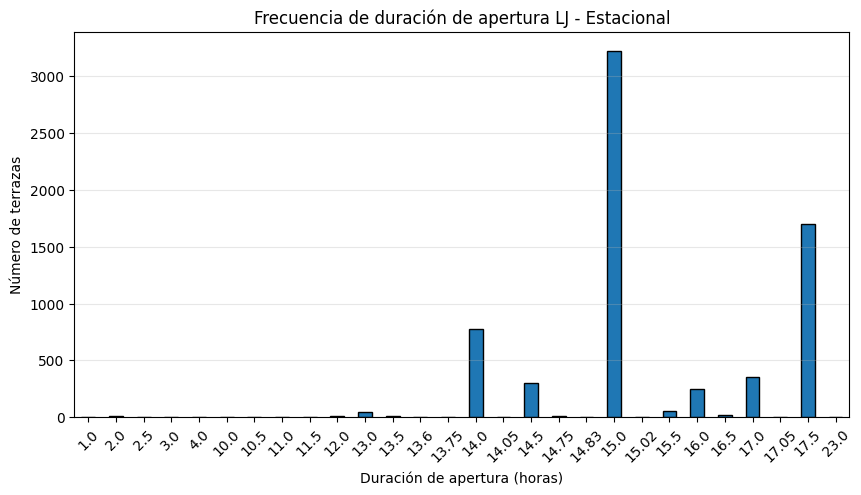

In [86]:
conteo = (
    df["duracion_lj_es"]
    .dropna()
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

conteo.plot(kind="bar", edgecolor="black")

plt.title("Frecuencia de duración de apertura LJ - Estacional")
plt.xlabel("Duración de apertura (horas)")
plt.ylabel("Número de terrazas")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Normalizar coordenadas espaciales

In [87]:
df = df.pipe(unificar_coordenadas)

In [88]:
df.loc[(df["cod_postal"] == 28053) & (df["rotulo"] == "LA JAMBOTECA"), ["cod_postal", "desc_distrito_local", "desc_barrio_local", "desc_vial_edificio", "rotulo", "lon", "lat"]]

,cod_postal,desc_distrito_local,desc_barrio_local,desc_vial_edificio,rotulo,lon,lat
3089,28053,PUENTE DE VALLECAS,SAN DIEGO,PUERTO RUBIO,LA JAMBOTECA,-3.667392,40.396873


In [89]:
lon, lat = df.loc[(df["cod_postal"] == 28053) & (df["rotulo"] == "LA JAMBOTECA"), ["lon", "lat"]].iloc[0].to_list()

visualizar_coordenadas(lat, lon)

### Guardar el conjunto de datos resultante

In [90]:
df.to_csv(DATA_DIR / 'terrazas.csv', index=False)

##  Locales

### Descripción del fichero

[Contenido y estructura de los ficheros de locales](https://datos.madrid.es/dataset/200085-0-censo-locales/resource/200085-9-censo-locales).

#### Categoría: identificación y localización del local

| Campo | Descripción |
| :--- | :--- |
| `id_local` | Código numérico único del local (Portal + secuencial o Agrupación + planta + local). |
| `rotulo` | Nombre comercial del establecimiento. |
| `id_distrito_local` | Código numérico del distrito. |
| `desc_distrito_local` | Nombre del distrito. |
| `cod_barrio_local` | Código numérico del barrio (requiere el distrito para ser unívoco). |
| `id_barrio_local` | Código numérico del barrio (ya incluye el código de distrito). |
| `desc_barrio_local` | Nombre del barrio. |
| `id_seccion_censal_local` | Código de distrito + sección censal. |
| `desc_seccion_censal_local`| Código de la sección censal. |


#### Categoría: estado y acceso del local

| Campo | Descripción |
| :--- | :--- |
| `id_tipo_acceso_local` | Código del tipo de acceso. *(Ver Tabla A)* |
| `desc_tipo_acceso_local` | Literal del tipo de acceso. *(Ver Tabla A)* |
| `id_situacion_local` | Código de la situación de actividad actual. *(Ver Tabla B)* |
| `desc_situacion_local` | Literal de la situación del local. *(Ver Tabla B)* |


#### Categoría: dirección del edificio y acceso real

> *Nota: Si el acceso al local es el mismo que el portal del edificio, los datos del Bloque B serán idénticos a los del Bloque A.*

**Bloque A: Dirección del Edificio (Portal principal)**

| Campo | Descripción |
| :--- | :--- |
| `id_vial_edificio` | Código que identifica la clase + nombre de la vía. |
| `clase_vial_edificio` | Tipo de vía (Calle, Avenida, Plaza…). |
| `desc_vial_edificio` | Nombre de la vía según el callejero oficial. |
| `id_ndp_edificio` | Código numérico oficial de la dirección (ej: 11014430). |
| `Id_clase_ndp_edificio`| `1` (Oficial/Normalizada) o `9` (No normalizada). |
| `nom_edificio` | Tipo de numeración (Número, Kilómetro, bloque…). |
| `num_edificio` | Número de la vía. |
| `cal_edificio` | Calificador del número (A, B…). Puede ser nulo. |
| `secuencial_local_PC` | Número secuencial (saltos decenales: 10, 20...). Identifica el local en la fachada, de izquierda a derecha (sentido antihorario). |

**Bloque B: Dirección de Acceso al Local**

| Campo | Descripción |
| :--- | :--- |
| `id_vial_acceso` a `num_acceso` | Equivalentes a los del edificio, pero para el acceso real. |
| `cal_acceso` *(Originalmente errata `cal_edificio`)* | Calificador del número de acceso (A, B…, DUP). Puede ser nulo. |


#### Categoría: coordenadas y agrupaciones

| Campo | Descripción |
| :--- | :--- |
| `coordenadas x-y_local` | Coordenadas UTM aproximadas. Solo válidas para "Puerta de Calle" que no sean "Baja". *(ED-50 hasta 15/09/2017; ETRS89 posterior)*. |
| `coordenadas x-y_agrupación`| Coordenadas UTM de la entrada principal a la agrupación. |
| `id_agrupación` | Código de la agrupación. (`-1` para Puerta de calle). |
| `nombre_agrupación` | Nombre de la agrupación. (`"SIN AGRUPACION"` para Puerta de calle). |
| `id_tipo_agrup` | Código del tipo de agrupación. *(Ver Tabla C)* |
| `desc_tipo_agrup` | Literal del tipo de agrupación. *(Ver Tabla C)* |
| `id_planta_agrupado` | Planta en la que se ubica el local dentro de la agrupación. |
| `id_local_agrupado` | Número de local dentro de la agrupación. |


#### Categoría: tablas de referencia

**Tabla A: Tipos de Acceso (`id_tipo_acceso_local`, `desc_tipo_acceso_local`)**

* **0 - Agrupado:** Pertenece a agrupación (mercados, galerías). Solo la agrupación tiene coordenadas.
* **1 - Puerta de calle:** Acceso directo desde la calle.
* **12 - Puerta de calle asociado:** *No es un local físico.* Diferencia sub-actividades de otro titular dentro de un Puerta de Calle (ej. Cafetería en un hospital). **No sumar al contar locales físicos.**

**Tabla B: Situación del Local (`id_situacion_local`, `desc_situacion_local`)**

* **1 - Abierto**
* **4 - Cerrado**
* **5 - Uso vivienda**
* **7 - Obras**
* **8 - Baja **
* **9 - Baja R (Reunificación)**

**Tabla C: Tipos de Agrupación (`id_tipo_agrup`, `desc_tipo_agrup`)**

* **-1 - SIN AGRUPACION**
* **1 - Centro Comercial**
* **4 - Galería de alimentación**
* **7 - Intercambiador**
* **8 - Estación de tren**
* **9 - Estación de metro**
* **10 - Aeropuerto**
* **12 - Mercado Municipal**
* **13 - Pasaje comercial**
* **15 - No comercial**
* **16 - Recinto ferial**
* **17 - Mercamadrid**


### Análisis exploratorio (EDA)

In [91]:
df = pd.read_csv('https://docs.google.com/uc?id=1WMovHctAKyjh0si6pOtYI9aq3Ki84Lxv', sep=';', decimal='.', encoding='utf-8')

# Normalizamos el nombre de las columnas
clean_steps.append({
    "dataset": "locales",
    "columna": "todas",
    "ejemplo_valor": df.columns.to_series().sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "normalizar el nombre de las columnas",
    "funcion": inspect.getsource(normalize_column_name)
})
df = df.rename(columns=normalize_column_name)

df.head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_apertura2,hora_cierre1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin
0,20000596,2,ARGANZUELA,203,CHOPERA,3,2043,43,440788.6,4471857.5,1,Puerta Calle,1,Abierto,744250,CALLE,TOMAS BORRAS ...,11008969,1,NUM,12,,20,744250,CALLE,TOMAS BORRAS ...,11008969,1,NUM,12,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,D1,LA CAÑA,28045,09:00,NaN,NaN,22:00,2023-12-08 07:01:00.047,2023-12-01,2023-12-01
1,20000605,2,ARGANZUELA,201,IMPERIAL,1,2107,107,439316.6,4472540.5,1,Puerta Calle,1,Abierto,597700,GLORIETA,PIRAMIDES ...,11008222,1,NUM,6,,20,597700,GLORIETA,PIRAMIDES ...,11008222,1,NUM,6,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,CAFETERIA PIRAMIDES,28005,NaN,NaN,NaN,NaN,2023-12-08 07:01:00.047,2023-12-01,2023-12-01
2,20000669,2,ARGANZUELA,202,ACACIAS,2,2096,96,439770.6,4472407.5,1,Puerta Calle,1,Abierto,501150,CALLE,MELILLA ...,20123782,1,NUM,39,,50,501150,CALLE,MELILLA ...,20123782,1,NUM,39,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,M1,BAR MELILLA,28005,NaN,NaN,NaN,NaN,2023-12-08 07:01:00.047,2023-12-01,2023-12-01
3,20000709,2,ARGANZUELA,202,ACACIAS,2,2029,29,440355.6,4472282.5,1,Puerta Calle,1,Abierto,274600,PASEO,ESPERANZA ...,11008673,1,NUM,45,,10,274600,PASEO,ESPERANZA ...,11008673,1,NUM,45,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,IZ,SUPERMERCADOS SIMPLY,28005,NaN,NaN,NaN,NaN,2023-12-08 07:01:00.047,2023-12-01,2023-12-01
4,20000721,2,ARGANZUELA,201,IMPERIAL,1,2089,89,439312.6,4472870.5,1,Puerta Calle,1,Abierto,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS ...,20106307,1,NUM,54,,40,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS ...,20106307,1,NUM,54,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,C,ARROCERIA IMPERIAL,28005,NaN,NaN,NaN,NaN,2023-12-08 07:01:00.047,2023-12-01,2023-12-01


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151162 entries, 0 to 151161
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_local                   151162 non-null  int64  
 1   id_distrito_local          151162 non-null  int64  
 2   desc_distrito_local        151162 non-null  object 
 3   id_barrio_local            151162 non-null  int64  
 4   desc_barrio_local          151162 non-null  object 
 5   cod_barrio_local           151162 non-null  int64  
 6   id_seccion_censal_local    151162 non-null  int64  
 7   desc_seccion_censal_local  151162 non-null  int64  
 8   coordenada_x_local         151162 non-null  float64
 9   coordenada_y_local         151162 non-null  float64
 10  id_tipo_acceso_local       151162 non-null  int64  
 11  desc_tipo_acceso_local     151162 non-null  object 
 12  id_situacion_local         151162 non-null  int64  
 13  desc_situacion_local       15

In [93]:
missing_data(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_apertura2,hora_cierre1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin
Total,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136661,136661,0,0,0,0,1648,60717,0,0,142366,150350,144851,150300,0,0,0
Porcentaje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.406981,90.406981,0.0,0.0,0.0,0.0,1.090221,40.166841,0.0,0.0,94.181077,99.462828,95.825009,99.429751,0.0,0.0,0.0
Tipos,int64,int64,object,int64,object,int64,int64,int64,float64,float64,int64,object,int64,object,int64,object,object,int64,int64,object,int64,object,int64,int64,object,object,int64,int64,object,int64,object,float64,float64,int64,object,int64,object,object,object,object,int64,object,object,object,object,object,object,object


Los horarios de apertura y cierre: `hora_apertura1`, `hora_apertura2`, `hora_cierre1`, `hora_cierre2` son nulos en más del 94% de los registros de locales.

**NOTA:**

Estas columnas no vienen informadas en la descripción del contenido del dataset.

In [94]:
unique_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_apertura2,hora_cierre1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin
Total,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,14501,14501,151162,151162,151162,151162,149514,90445,151162,151162,8796,812,6311,862,151162,151162,151162
Valores únicos,151162,21,21,131,131,9,2418,222,37975,20327,3,3,7,7,6393,25,6161,65696,1,2,681,30,286,6555,25,6303,72142,1,2,691,31,365,360,426,417,12,12,20,3467,80142,55,63,37,56,34,112,1,1


En el dataset de locales el identificador `id_local` es único.

In [95]:
most_frequent_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_apertura2,hora_cierre1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin
Total,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,151162,14501,14501,151162,151162,151162,151162,149514,90445,151162,151162,8796,812,6311,862,151162,151162,151162
Valor más frecuente,300022017,1,CENTRO,1701,SAN ANDRES,1,18046,46,0.0,0.0,1,Puerta Calle,1,Abierto,88952587,CALLE,ALCALA ...,31025055,1,NUM,1,,10,88952587,CALLE,ALCALA ...,31049013,1,NUM,1,,0.0,0.0,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SIN ACTIVIDAD,28017,08:00,10:00,02:00,02:00,2023-12-08 07:01:00.937,2023-12-01,2023-12-01
Frecuencia,1,13440,13440,4092,4092,28949,1814,3000,14350,14350,134010,134010,99664,99664,1431,125753,1431,252,151162,151087,6523,142931,67211,1375,125646,1375,282,151162,151083,6441,142870,1586,1586,136661,136661,136661,136661,143646,20570,39418,5824,1977,435,3063,461,2434,151162,151162
Porcentaje del total,0.001,8.891,8.891,2.707,2.707,19.151,1.2,1.985,9.493,9.493,88.653,88.653,65.932,65.932,0.947,83.191,0.947,0.167,100.0,99.95,4.315,94.555,44.463,0.91,83.12,0.91,0.187,100.0,99.948,4.261,94.514,10.937,10.937,90.407,90.407,90.407,90.407,96.075,22.743,26.077,3.853,22.476,53.571,48.534,53.48,1.61,100.0,100.0


#### Convertir valores centinela a nulos

Mantenemos las descripciones, pero sustituimos por nulos los valores centinela de los campos codificados.

In [96]:
centinelas = {
    "id_agrupacion": -1,
    "id_tipo_agrup": -1,
    "coordenada_x_local": 0.0,
    "coordenada_y_local": 0.0,
    "coordenada_x_agrupacion": 0.0,
    "coordenada_y_agrupacion": 0.0
}

for col, valores in centinelas.items():
    clean_steps.append({
        "dataset": "locales",
        "columna": col,
        "ejemplo_valor": valores,
        "impacto": "medio",
        "accion_sugerida": "convertir a nulos",
        "funcion": inspect.getsource(sentinel_to_null)
    })

#### Eliminar columnas

In [97]:
for col in ["fx_carga", "fx_datos_ini", "fx_datos_fin"]:
    clean_steps.append({
        "dataset": "locales",
        "columna": col,
        "ejemplo_valor": df[col].sample(1, random_state=42).item(),
        "impacto": "bajo",
        "accion_sugerida": "eliminar",
        "funcion": inspect.getsource(drop_columns)
    })

#### Normalizar campos de texto

In [98]:
clean_steps.append({
    "dataset": "locales",
    "columna": "columnas de tipo texto",
    "ejemplo_valor": repr(df['desc_distrito_local'].sample(1, random_state=42).item()),
    "impacto": "alto",
    "accion_sugerida": "normalizar textos: sin espacios iniciales/finales, mayúsculas, suprimir tildes",
        "funcion": "\n".join([
        inspect.getsource(normalize_str),
        inspect.getsource(normalize_str_cols)
    ])
})

#### Convertir campos de fecha y hora

- Los campos `hora_apertura1`, `hora_apertura2`, `hora_cierre1` y `hora_cierre2` ya están en formato **hh:mm**, por lo que no se transforman.
- Creamos las columnas `duracion1` y `duracion2` con el tiempo de apertura de cada local en horas.

In [99]:
for col in ["duracion1", "duracion2"]:
    clean_steps.append({
        "dataset": "locales",
        "columna": col,
        "ejemplo_valor": 10.5,
        "impacto": "bajo",
        "accion_sugerida": "crear columna con el tiempo de apertura de cada local",
        "funcion": inspect.getsource(create_duracion_column)
    })

#### Normalizar coordenadas espaciales

In [100]:
for axis in ["x", "y"]:
    clean_steps.append({
        "dataset": "locales",
        "columna": f"coordenada_{axis}_local + coordenada_{axis}_agrupacion = coordenada_{axis}",
        "ejemplo_valor": pd.NA,
        "impacto": "alto",
        "accion_sugerida": """unificar coordenadas, cuando id_tipo_acceso_local=1 se usa las de _local
            cuando id_tipo_acceso_local=0 se usa _agrupacion y convertir a latitud, longitud""",
        "funcion": inspect.getsource(unificar_coordenadas)
    })

### Aplicación de transformaciones

In [101]:
is_terrazas = lambda row: row.get("dataset", "") == "locales"

clean_df = pd.DataFrame(filter(is_terrazas, clean_steps))

clean_df

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
0,locales,todas,id_clase_ndp_acceso,alto,normalizar el nombre de las columnas,"def normalize_column_name(col):\n """"""\n ..."
1,locales,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,locales,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,locales,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,locales,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,locales,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,locales,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
7,locales,fx_carga,2023-12-08 07:01:00.803,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
8,locales,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
9,locales,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."


#### Convertir valores centinela a nulos

In [102]:
clean_df[clean_df['accion_sugerida'].str.contains("nulos")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
1,locales,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,locales,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,locales,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,locales,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,locales,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,locales,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


In [103]:
# Convertir valores sentinela a nulos
columns = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "columna"].to_list()
sentinels = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "ejemplo_valor"].to_list()

df = df.pipe(sentinel_to_null, columns, sentinels)

In [104]:
# Valores nulos tras la conversión

missing_data(df[columns])

,id_agrupacion,id_tipo_agrup,coordenada_x_local,coordenada_y_local,coordenada_x_agrupacion,coordenada_y_agrupacion
Total,136661,136661,14350,14350,138247,138247
Porcentaje,90.406981,90.406981,9.493127,9.493127,91.456186,91.456186
Tipos,Int64,Int64,float64,float64,float64,float64


#### Eliminas columnas

In [105]:
clean_df[clean_df['accion_sugerida'] == "eliminar"]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
7,locales,fx_carga,2023-12-08 07:01:00.803,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
8,locales,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
9,locales,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."


In [106]:
columns=clean_df.loc[clean_df['accion_sugerida'] == "eliminar", "columna"]
df = df.drop(columns=columns)

df.columns

Index(['id_local', 'id_distrito_local', 'desc_distrito_local',
       'id_barrio_local', 'desc_barrio_local', 'cod_barrio_local',
       'id_seccion_censal_local', 'desc_seccion_censal_local',
       'coordenada_x_local', 'coordenada_y_local', 'id_tipo_acceso_local',
       'desc_tipo_acceso_local', 'id_situacion_local', 'desc_situacion_local',
       'id_vial_edificio', 'clase_vial_edificio', 'desc_vial_edificio',
       'id_ndp_edificio', 'id_clase_ndp_edificio', 'nom_edificio',
       'num_edificio', 'cal_edificio', 'secuencial_local_pc', 'id_vial_acceso',
       'clase_vial_acceso', 'desc_vial_acceso', 'id_ndp_acceso',
       'id_clase_ndp_acceso', 'nom_acceso', 'num_acceso', 'cal_acceso',
       'coordenada_x_agrupacion', 'coordenada_y_agrupacion', 'id_agrupacion',
       'nombre_agrupacion', 'id_tipo_agrup', 'desc_tipo_agrup',
       'id_planta_agrupado', 'id_local_agrupado', 'rotulo', 'cod_postal',
       'hora_apertura1', 'hora_apertura2', 'hora_cierre1', 'hora_cierre2'],
     

#### Normalizar campos de texto

In [107]:
df = df.pipe(normalize_str_cols)

Normalizando columna: desc_distrito_local, tipo: object
Normalizando columna: desc_barrio_local, tipo: object
Normalizando columna: desc_tipo_acceso_local, tipo: object
Normalizando columna: desc_situacion_local, tipo: object
Normalizando columna: clase_vial_edificio, tipo: object
Normalizando columna: desc_vial_edificio, tipo: object
Normalizando columna: nom_edificio, tipo: object
Normalizando columna: cal_edificio, tipo: object
Normalizando columna: clase_vial_acceso, tipo: object
Normalizando columna: desc_vial_acceso, tipo: object
Normalizando columna: nom_acceso, tipo: object
Normalizando columna: cal_acceso, tipo: object
Normalizando columna: nombre_agrupacion, tipo: object
Normalizando columna: desc_tipo_agrup, tipo: object
Normalizando columna: id_planta_agrupado, tipo: object
Normalizando columna: id_local_agrupado, tipo: object
Normalizando columna: rotulo, tipo: object
Normalizando columna: hora_apertura1, tipo: object
Normalizando columna: hora_apertura2, tipo: object
Norm

#### Convertir campos de fecha y hora

In [108]:
clean_df[clean_df['accion_sugerida'].str.contains(r"tiempo de apertura")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
11,locales,duracion1,10.5,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."
12,locales,duracion2,10.5,bajo,crear columna con el tiempo de apertura de cad...,"def create_duracion_column(data, col_names, ho..."


In [109]:
duraciones = {
    "duracion1": ["hora_apertura1", "hora_cierre1"],
    "duracion2": ["hora_apertura2", "hora_cierre2"]
}

df = df.pipe(create_duracion_column, duraciones.keys(), duraciones.values())
df[duraciones.keys()].head()

,duracion1,duracion2
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


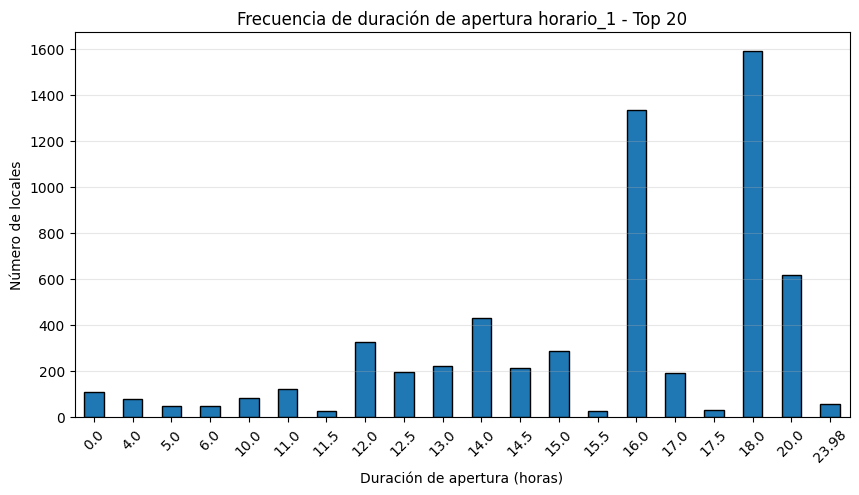

In [110]:
conteo = (
    df["duracion1"]
    .dropna()
    .value_counts()
    .head(20)
    .sort_index()
)

plt.figure(figsize=(10, 5))

conteo.plot(kind="bar", edgecolor="black")

plt.title("Frecuencia de duración de apertura horario_1 - Top 20")
plt.xlabel("Duración de apertura (horas)")
plt.ylabel("Número de locales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Normalizar coordenadas espaciales

In [111]:
df = df.pipe(unificar_coordenadas)

In [112]:
df.loc[(df["cod_postal"] == 28053) & (df["desc_barrio_local"] == "SAN DIEGO"), ["cod_postal", "desc_distrito_local", "desc_barrio_local", "desc_vial_edificio", "rotulo", "lon", "lat"]].sample(1, random_state=21)

,cod_postal,desc_distrito_local,desc_barrio_local,desc_vial_edificio,rotulo,lon,lat
147524,28053,PUENTE DE VALLECAS,SAN DIEGO,EDUARDO REQUENAS,CENTRO DE YOGA,-3.66639,40.389599


In [113]:
lon, lat = df.loc[(df["cod_postal"] == 28053) & (df["desc_barrio_local"] == "SAN DIEGO"), ["lon", "lat"]].sample(1, random_state=21).iloc[0].to_list()

visualizar_coordenadas(lat, lon)

### Guardar el conjunto de datos resultante

In [114]:
df.to_csv(DATA_DIR / 'locales.csv', index=False)

## Actividades

### Descripción del fichero

[Contenido y estructura de los ficheros de actividades](https://datos.madrid.es/dataset/200085-0-censo-locales/resource/200085-9-censo-locales).

#### Categoría: campos propios de actividades

Estas variables detallan la actividad económica mediante un sistema jerárquico propio del Ayuntamiento (basado en el antiguo I.A.E., pero cuyas Secciones y Divisiones están alineadas con la **CNAE-09** del INE).

| Campo | Descripción |
| :--- | :--- |
| `id_seccion` | Código de "Sección" de actividad (1 letra, ej: "G"). (CNAE-09) |
| `desc_seccion` | Literal de la Sección (ej: "Comercio al por mayor y menor"). |
| `id_division` | Código de "División" de actividad (2 dígitos). (CNAE-09) |
| `desc_division` | Literal de la División. |
| `ide_epigrafe` | Código de epígrafe detallado (Ayuntamiento). Empieza por los 2 dígitos de la división. |
| `desc_epigrafe` | Literal del epígrafe de la actividad. |


### Análisis exploratorio (EDA)

El fichero de actividades es demasiado grande por lo que no se puede acceder directamente a través de la URL `https://docs.google.com/uc?id=FILE_ID`, es necesario descargarlo.

In [115]:
import requests
from io import BytesIO

file_id = "1W7ewwd2Hdz14eo5lj57bVWInNotC9xmF"
url = "https://drive.usercontent.google.com/download"

params = {
    "id": file_id,
    "export": "download",
    "confirm": "t"
}

response = requests.get(url, params=params)

In [116]:
# Aunque la documentación indica que `id_division` está compuesto por 2 dígitos, hay divisiones compuestas por dos letras, como **PT**.
# Por eso declaramos el tipo explícitamente.
df = pd.read_csv(BytesIO(response.content), sep=';', decimal='.', encoding='utf-8', dtype={
        "id_division": "string",
        "id_epigrafe": "string",
})

# Normalizamos el nombre de las columnas
clean_steps.append({
    "dataset": "actividades",
    "columna": "todas",
    "ejemplo_valor": df.columns.to_series().sample(1, random_state=42).item(),
    "impacto": "alto",
    "accion_sugerida": "normalizar el nombre de las columnas",
    "funcion": inspect.getsource(normalize_column_name)
})
df = df.rename(columns=normalize_column_name)

df.head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
0,270574777,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,12,PC Asociado,1,Abierto,67900,CALLE,ARCOS DE JALON ...,31026116,1,NUM,34,,10,67900,CALLE,ARCOS DE JALON ...,31026116,1,NUM,34,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,CAMPAMENTO DE VERANO CEIP MARIA MOLINER,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.89,2023-12-01,2023-12-01
1,270574779,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,12,PC Asociado,1,Abierto,67900,CALLE,ARCOS DE JALON ...,31024172,1,NUM,22,,10,67900,CALLE,ARCOS DE JALON ...,31024172,1,NUM,22,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,CAMPAMENTO VERANO CEE FUNDACION GOYENECHE,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.89,2023-12-01,2023-12-01
2,270574786,11,CARABANCHEL,1101,COMILLAS,1,11013,13,0.00,0.0,12,PC Asociado,1,Abierto,89200,CALLE,BALEARES ...,31008181,1,NUM,18,,10,89200,CALLE,BALEARES ...,31008181,1,NUM,18,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,COLEGIO PUBLICO PERU,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.89,2023-12-01,2023-12-01
3,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,1,Puerta Calle,1,Abierto,31001734,CALLE,JOSE ANTONIO FERNANDEZ ORDOÑEZ ...,31039136,1,NUM,38,,10,31001744,AVENIDA,MANUEL FRAGA IRIBARNE ...,31062109,1,NUM,62,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472206,"COMERCIO AL POR MENOR DE AVES, HUEVOS Y CAZA S...",2023-12-08 07:00:45.89,2023-12-01,2023-12-01
4,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,1,Puerta Calle,1,Abierto,31001734,CALLE,JOSE ANTONIO FERNANDEZ ORDOÑEZ ...,31039136,1,NUM,38,,10,31001744,AVENIDA,MANUEL FRAGA IRIBARNE ...,31062109,1,NUM,62,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472401,COMERCIO AL POR MENOR DE PAN Y PRODUCTOS DE PA...,2023-12-08 07:00:45.89,2023-12-01,2023-12-01


In [117]:
# Ejemplo de divisiones compuestas por dos caracteres

df.loc[df["id_division"] == "PT", ["id_division", "id_epigrafe"]].head()

,id_division,id_epigrafe
4238,PT,PTECO1
4297,PT,PTECO1
7156,PT,PTECO1
14830,PT,PTECO1
15381,PT,PTECO1


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169559 entries, 0 to 169558
Data columns (total 49 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_local                   169559 non-null  int64  
 1   id_distrito_local          169559 non-null  int64  
 2   desc_distrito_local        169559 non-null  object 
 3   id_barrio_local            169559 non-null  int64  
 4   desc_barrio_local          169559 non-null  object 
 5   cod_barrio_local           169559 non-null  int64  
 6   id_seccion_censal_local    169559 non-null  int64  
 7   desc_seccion_censal_local  169559 non-null  int64  
 8   coordenada_x_local         169559 non-null  float64
 9   coordenada_y_local         169559 non-null  float64
 10  id_tipo_acceso_local       169559 non-null  int64  
 11  desc_tipo_acceso_local     169559 non-null  object 
 12  id_situacion_local         169559 non-null  int64  
 13  desc_situacion_local       16

In [119]:
missing_data(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
Total,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,153427,153427,0,0,0,0,1869,64940,0,0,0,0,0,0,0,0,0,0
Porcentaje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.485908,90.485908,0.0,0.0,0.0,0.0,1.102271,38.299353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tipos,int64,int64,object,int64,object,int64,int64,int64,float64,float64,int64,object,int64,object,int64,object,object,int64,int64,object,int64,object,int64,int64,object,object,int64,int64,object,int64,object,float64,float64,int64,object,int64,object,object,object,object,object,object,string[python],object,string[python],object,object,object,object


In [120]:
unique_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
Total,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,16132,16132,169559,169559,169559,169559,167690,104619,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559
Valores únicos,151161,21,21,131,131,9,2418,222,37975,20327,3,3,7,7,6393,25,6161,65696,1,2,681,30,286,6555,25,6303,72142,1,2,691,31,365,360,426,417,12,12,20,3467,80141,22,22,83,83,439,439,121,1,1


En el dataset de actividades no existe un campo que actúe como identificador único: un local (`id_local`) puede ejercer diferentes actividades.

In [121]:
df.loc[df["id_local"] == 270415106, ["id_local", "rotulo", "id_seccion", "desc_seccion", "id_division",	"desc_division", "id_epigrafe",	"desc_epigrafe"]]

,id_local,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe
65786,270415106,CASH ECOFAMILIA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472402,COMERCIO AL POR MENOR DE PAN Y PRODUCTOS DE PA...
66063,270415106,CASH ECOFAMILIA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",471102,COMERCIO AL POR MENOR EN ESTABLECIMIENTOS NO E...
67499,270415106,CASH ECOFAMILIA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472201,COMERCIO AL POR MENOR DE CARNICERIA
69367,270415106,CASH ECOFAMILIA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472302,COMERCIO AL POR MENOR DE PESCADOS Y MARISCOS S...


In [122]:
most_frequent_values(df)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
Total,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559,16132,16132,169559,169559,169559,169559,167690,104619,169559,169559,169559,169559,169559,169559,169559,169559,169559,169559
Valor más frecuente,270552973,1,CENTRO,1701,SAN ANDRES,1,18046,46,0.0,0.0,1,Puerta Calle,1,Abierto,88952587,CALLE,ALCALA ...,31025055,1,NUM,1,,10,88952587,CALLE,ALCALA ...,31049013,1,NUM,1,,0.0,0.0,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SIN ACTIVIDAD,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",-1,VALOR NULO EN ORIGEN,2023-12-08 07:00:44.897,2023-12-01,2023-12-01
Frecuencia,14,14815,14815,4485,4485,32196,2064,3373,15667,15667,150383,150383,116596,116596,1657,140442,1657,291,169559,169461,7360,160122,76740,1613,140222,1613,330,169559,169456,7199,160201,1695,1695,153427,153427,153427,153427,161116,24606,39419,51516,51516,44670,44670,39292,39292,2372,169559,169559
Porcentaje del total,0.008,8.737,8.737,2.645,2.645,18.988,1.217,1.989,9.24,9.24,88.691,88.691,68.764,68.764,0.977,82.828,0.977,0.172,100.0,99.942,4.341,94.434,45.259,0.951,82.698,0.951,0.195,100.0,99.939,4.246,94.481,10.507,10.507,90.486,90.486,90.486,90.486,96.08,23.52,23.248,30.382,30.382,26.345,26.345,23.173,23.173,1.399,100.0,100.0


#### Convertir valores centinela a nulos


Mantenemos las descripciones, pero sustituimos por nulos los valores sentinela de los campos codificados.

In [123]:
centinelas = {
    "id_agrupacion": -1,
    "id_tipo_agrup": -1,
    "id_seccion": "-1",
    "id_division": "-1",
    "id_epigrafe": "-1",
    "coordenada_x_local": 0.0,
    "coordenada_y_local": 0.0,
    "coordenada_x_agrupacion": 0.0,
    "coordenada_y_agrupacion": 0.0
}

for col, valores in centinelas.items():
    clean_steps.append({
        "dataset": "actividades",
        "columna": col,
        "ejemplo_valor": valores,
        "impacto": "medio",
        "accion_sugerida": "convertir a nulos",
        "funcion": inspect.getsource(sentinel_to_null)
    })

#### Eliminar columnas

In [124]:
for col in ["fx_carga", "fx_datos_ini", "fx_datos_fin"]:
    clean_steps.append({
        "dataset": "actividades",
        "columna": col,
        "ejemplo_valor": df[col].sample(1, random_state=42).item(),
        "impacto": "bajo",
        "accion_sugerida": "eliminar",
        "funcion": inspect.getsource(drop_columns)
    })

#### Normalizar campos de texto

In [125]:
clean_steps.append({
    "dataset": "actividades",
    "columna": "columnas de tipo texto",
    "ejemplo_valor": repr(df['desc_distrito_local'].iloc[0]),
    "impacto": "alto",
    "accion_sugerida": "normalizar textos: sin espacios iniciales/finales, mayúsculas, suprimir tildes",
    "funcion": "\n".join([
        inspect.getsource(normalize_str),
        inspect.getsource(normalize_str_cols)
    ])
})

#### Normalizar coordenadas espaciales


In [126]:
for axis in ["x", "y"]:
    clean_steps.append({
        "dataset": "actividades",
        "columna": f"[coordenada_{axis}_local, coordenada_{axis}_agrupacion]",
        "ejemplo_valor": pd.NA,
        "impacto": "alto",
        "accion_sugerida": """unificar coordenadas, cuando id_tipo_acceso_local=1 se usa las de _local
            cuando id_tipo_acceso_local=0 se usa _agrupacion y convertir a latitud, longitud""",
        "funcion": inspect.getsource(unificar_coordenadas)
    })

### Aplicación de transformaciones

In [127]:
is_terrazas = lambda row: row.get("dataset", "") == "actividades"

clean_df = pd.DataFrame(filter(is_terrazas, clean_steps))

clean_df

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
0,actividades,todas,desc_situacion_local,alto,normalizar el nombre de las columnas,"def normalize_column_name(col):\n """"""\n ..."
1,actividades,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,actividades,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,actividades,id_seccion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,actividades,id_division,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,actividades,id_epigrafe,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,actividades,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
7,actividades,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
8,actividades,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
9,actividades,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


#### Convertir valores centinela a nulos

In [128]:
clean_df[clean_df['accion_sugerida'].str.contains("nulos")]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
1,actividades,id_agrupacion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
2,actividades,id_tipo_agrup,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
3,actividades,id_seccion,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
4,actividades,id_division,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
5,actividades,id_epigrafe,-1,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
6,actividades,coordenada_x_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
7,actividades,coordenada_y_local,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
8,actividades,coordenada_x_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."
9,actividades,coordenada_y_agrupacion,0.0,medio,convertir a nulos,"def sentinel_to_null(data, columns, sentinels)..."


In [129]:
# Convertir valores centinela a nulos

columns = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "columna"].to_list()
sentinels = clean_df.loc[clean_df['accion_sugerida'].str.contains("nulos"), "ejemplo_valor"].to_list()

df = df.pipe(sentinel_to_null, columns, sentinels)

In [130]:
# Valores nulos tras la conversión

missing_data(df[columns])

,id_agrupacion,id_tipo_agrup,id_seccion,id_division,id_epigrafe,coordenada_x_local,coordenada_y_local,coordenada_x_agrupacion,coordenada_y_agrupacion
Total,153427,153427,39292,39292,39292,15667,15667,155122,155122
Porcentaje,90.485908,90.485908,23.173055,23.173055,23.173055,9.239852,9.239852,91.48556,91.48556
Tipos,Int64,Int64,object,string[python],string[python],float64,float64,float64,float64


#### Eliminas columnas

In [131]:
clean_df[clean_df['accion_sugerida'] == "eliminar"]

,dataset,columna,ejemplo_valor,impacto,accion_sugerida,funcion
10,actividades,fx_carga,2023-12-08 07:00:45.883,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
11,actividades,fx_datos_ini,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."
12,actividades,fx_datos_fin,2023-12-01,bajo,eliminar,"def drop_columns(df, columns):\n return df...."


In [132]:
columns=clean_df.loc[clean_df['accion_sugerida'] == "eliminar", "columna"]
df = df.drop(columns=columns)

df.columns

Index(['id_local', 'id_distrito_local', 'desc_distrito_local',
       'id_barrio_local', 'desc_barrio_local', 'cod_barrio_local',
       'id_seccion_censal_local', 'desc_seccion_censal_local',
       'coordenada_x_local', 'coordenada_y_local', 'id_tipo_acceso_local',
       'desc_tipo_acceso_local', 'id_situacion_local', 'desc_situacion_local',
       'id_vial_edificio', 'clase_vial_edificio', 'desc_vial_edificio',
       'id_ndp_edificio', 'id_clase_ndp_edificio', 'nom_edificio',
       'num_edificio', 'cal_edificio', 'secuencial_local_pc', 'id_vial_acceso',
       'clase_vial_acceso', 'desc_vial_acceso', 'id_ndp_acceso',
       'id_clase_ndp_acceso', 'nom_acceso', 'num_acceso', 'cal_acceso',
       'coordenada_x_agrupacion', 'coordenada_y_agrupacion', 'id_agrupacion',
       'nombre_agrupacion', 'id_tipo_agrup', 'desc_tipo_agrup',
       'id_planta_agrupado', 'id_local_agrupado', 'rotulo', 'id_seccion',
       'desc_seccion', 'id_division', 'desc_division', 'id_epigrafe',
       'des

#### Normalizar campos de texto

In [133]:
df = df.pipe(normalize_str_cols)

Normalizando columna: desc_distrito_local, tipo: object
Normalizando columna: desc_barrio_local, tipo: object
Normalizando columna: desc_tipo_acceso_local, tipo: object
Normalizando columna: desc_situacion_local, tipo: object
Normalizando columna: clase_vial_edificio, tipo: object
Normalizando columna: desc_vial_edificio, tipo: object
Normalizando columna: nom_edificio, tipo: object
Normalizando columna: cal_edificio, tipo: object
Normalizando columna: clase_vial_acceso, tipo: object
Normalizando columna: desc_vial_acceso, tipo: object
Normalizando columna: nom_acceso, tipo: object
Normalizando columna: cal_acceso, tipo: object
Normalizando columna: nombre_agrupacion, tipo: object
Normalizando columna: desc_tipo_agrup, tipo: object
Normalizando columna: id_planta_agrupado, tipo: object
Normalizando columna: id_local_agrupado, tipo: object
Normalizando columna: rotulo, tipo: object
Normalizando columna: id_seccion, tipo: object
Normalizando columna: desc_seccion, tipo: object
Normalizan

#### Normalizar coordenadas espaciales

In [134]:
df = df.pipe(unificar_coordenadas)

In [135]:
df.loc[df["id_local"] == 270415106, ["id_local", "desc_distrito_local", "desc_barrio_local", "desc_vial_edificio", "rotulo", "lon", "lat"]]

,id_local,desc_distrito_local,desc_barrio_local,desc_vial_edificio,rotulo,lon,lat
65786,270415106,PUENTE DE VALLECAS,SAN DIEGO,MARTINEZ DE LA RIVA,CASH ECOFAMILIA,-3.664916,40.389454
66063,270415106,PUENTE DE VALLECAS,SAN DIEGO,MARTINEZ DE LA RIVA,CASH ECOFAMILIA,-3.664916,40.389454
67499,270415106,PUENTE DE VALLECAS,SAN DIEGO,MARTINEZ DE LA RIVA,CASH ECOFAMILIA,-3.664916,40.389454
69367,270415106,PUENTE DE VALLECAS,SAN DIEGO,MARTINEZ DE LA RIVA,CASH ECOFAMILIA,-3.664916,40.389454


In [136]:
lon, lat = df.loc[df["id_local"] == 270415106, ["lon", "lat"]].iloc[0].to_list()

visualizar_coordenadas(lat, lon)

### Guardar el conjunto de datos resultante

In [137]:
df.to_csv(DATA_DIR / 'actividades.csv', index=False)

## Resumen de transformaciones


Guardamos en **CSV** las transformaciones realizadas sobre cada uno de los ficheros.

In [138]:
clean_df = pd.DataFrame(clean_steps)

clean_df.to_csv(DATA_DIR / 'clean_steps.csv', index=False)

**NOTA:**

Los ficheros transformados están alojados como públicos en mi Google Drive.

- [licencias.csv](https://drive.google.com/file/d/1JAmIgPa7K4tNg8M2scausqLbzJYDdt1F/view?usp=drive_link) **(FILE_ID: 1JAmIgPa7K4tNg8M2scausqLbzJYDdt1F)**.
- [terrazas.csv](https://drive.google.com/file/d/1tM9opF8pwDhdFp7CslnlRiLFULGhONhU/view?usp=drive_link) **(FILE_ID: 1tM9opF8pwDhdFp7CslnlRiLFULGhONhU)**.
- [locales.csv](https://drive.google.com/file/d/1nBXoHn16Jj5aOrlWD1RBGUacetlYidzS/view?usp=drive_link) **(FILE_ID: 1nBXoHn16Jj5aOrlWD1RBGUacetlYidzS)**.
- [actividades.csv](https://drive.google.com/file/d/1fwpWEaS-R-l8aRvvQXb7fSiyjzp5k-Qa/view?usp=drive_link) **(FILE_ID: 1fwpWEaS-R-l8aRvvQXb7fSiyjzp5k-Qa)**.
- [clean_steps.csv](https://drive.google.com/file/d/1Dk7EXdBnMTya0rs-FGtL5msnJh1gnmrJ/view?usp=drive_link) **(FILE_ID: 1Dk7EXdBnMTya0rs-FGtL5msnJh1gnmrJ)**.

## Modelado de datos para MongoDB

El patrón de diseño escogido para modelar los datos para MongoDB es un patrón de documentos incrustados:

- **locales:** Documento raíz, utilizaremos `id_local` como `_id`.
- **terrazas:** Relación **uno a uno**.
- **licencias:** Relación **uno a muchos**.
- **actividades:** Relación **uno a muchos**.

El patrón propuesto es el siguiente:

```json
{
  "_id": 270415106,
  "rotulo": "CASH ECOFAMILIA",
  "location": {"type": "Point", "coordinates": [-3.664916, 40.389454]},
  "licencias": [{"ref_licencia": "...", "fecha_dec_lic": "..."}],
  "terraza": {"id_terraza": 123, "superficie_es": 10.5},
  "actividades": [{"id_epigrafe": "472402", "desc_epigrafe": "..."}]
}
```

Preparamos la carga de las datos con el patrón propuesto con **100 locales aleatorios** de ejemplo.

In [139]:
SAMPLE=25_000

locales = pd.read_csv(DATA_DIR / 'locales.csv')
locales = locales.sample(SAMPLE, random_state=42)

# Lista con los ids de los locales sampleados aleaoriamente
ids_local = locales['id_local'].to_numpy()

# Set para eliminar la información ya presente en locales del resto de ficheros
local_fields = set(locales.columns) - {"id_local"}

In [140]:
# Obtenemos el resto de informacion relativa a esos locales del resto de ficheros,
# nos quedamos solo con los campos únicos
def sample_data(data, ids_locals, local_fields):
    """
    Función auxilizar para preparar los datos para incrustarlos en locales.
    """
    df = data.copy()
    if ids_locals is not None:
        df = df.loc[df['id_local'].isin(ids_locals)]
    if local_fields is not None:
        df = df.drop(columns=[col for col in local_fields if col in data.columns])
    return df

licencias = pd.read_csv(DATA_DIR / 'licencias.csv', parse_dates=["fecha_dec_lic"])
licencias = sample_data(licencias, ids_local, local_fields)

terrazas = pd.read_csv(DATA_DIR / 'terrazas.csv', parse_dates=["fecha_confir_ult_decreto_resol"])
terrazas = sample_data(terrazas, ids_local, local_fields)

actividades = pd.read_csv(DATA_DIR / 'actividades.csv', dtype={
    "id_division": "string",
    "id_epigrafe": "string",
})
actividades = sample_data(actividades, ids_local, local_fields)


print(f"Para los {SAMPLE} locales escogidos aleatoriamente hay:")
print(f"    - {terrazas.shape[0]} terrazas")
print(f"    - {licencias.shape[0]} licencias")
print(f"    - {actividades.shape[0]} actividades")

Para los 25000 locales escogidos aleatoriamente hay:
    - 1129 terrazas
    - 24875 licencias
    - 28128 actividades


In [ ]:
def group_one(df, colname):
    """
    Agrupa una relacion 1:1 como un único documento.
    """
    return (
        df
        .set_index("id_local")
        .apply(lambda row: json.loads(row.to_json(force_ascii=False, date_format="iso")), axis=1)
        .rename(colname)
    )


def group_many(df, colname):
    """
    Agrupa una relacion 1:n como una lista de documentos.
    """
    value_cols = [col for col in df.columns if col != "id_local"]
    return (
        df
        .groupby("id_local")[value_cols]
        .apply(lambda group: json.loads(group.to_json(orient="records", force_ascii=False, date_format="iso")))
        .rename(colname)
    )


def make_geo(row):
    """
    Crea un punto GeoJSON a partir de las coordenadas.
    """
    lon = row.get("lon")
    lat = row.get("lat")
    if pd.notna(lon) and pd.notna(lat):
        return {
            "type": "Point",
            "coordinates": [lon, lat]
        }
    return None


terrazas_emb = group_one(terrazas, "terraza")
licencias_emb = group_many(licencias, "licencias")
actividades_emb = group_many(actividades, "actividades")

mongo_df = (
    locales
    .set_index("id_local")
    .join([terrazas_emb, licencias_emb, actividades_emb], how="left")
)


mongo_df["licencias"] = mongo_df["licencias"].apply(lambda x: x if isinstance(x, list) else [])
mongo_df["terraza"] = mongo_df["terraza"].apply(lambda x: x if isinstance(x, dict) else None)
mongo_df["actividades"] = mongo_df["actividades"].apply(lambda x: x if isinstance(x, list) else [])

mongo_df["location"] = mongo_df.apply(make_geo, axis=1)
mongo_df = mongo_df.drop(columns=["lon", "lat"])

mongo_df = mongo_df.reset_index()
mongo_df = mongo_df.rename(columns={ "id_local": "_id" })

mongo_df.head()

,_id,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,id_tipo_acceso_local,desc_tipo_acceso_local,...,hora_apertura1,hora_apertura2,hora_cierre1,hora_cierre2,duracion1,duracion2,terraza,licencias,actividades,location
0,280065005,19,VICALVARO,1901,CASCO H.VICALVARO,1,19009,9,1,PUERTA CALLE,...,NaN,NaN,NaN,NaN,NaN,NaN,None,[],"[{'id_seccion': 'L', 'desc_seccion': 'ACTIVIDA...","{'type': 'Point', 'coordinates': [-3.603840108..."
1,270516907,18,VILLA DE VALLECAS,1801,CASCO H.VALLECAS,1,18046,46,1,PUERTA CALLE,...,NaN,NaN,NaN,NaN,NaN,NaN,None,[],"[{'id_seccion': 'G', 'desc_seccion': 'COMERCIO...","{'type': 'Point', 'coordinates': [-3.629181535..."
2,270394185,4,SALAMANCA,404,GUINDALERA,4,4094,94,1,PUERTA CALLE,...,NaN,NaN,NaN,NaN,NaN,NaN,"{'id_terraza': 20044, 'escalera': None, 'id_pe...","[{'ref_licencia': '220/2010/03589', 'id_tipo_l...","[{'id_seccion': 'I', 'desc_seccion': 'HOSTELER...","{'type': 'Point', 'coordinates': [-3.673531273..."
3,270436129,13,PUENTE DE VALLECAS,1303,PALOMERAS BAJAS,3,13204,204,1,PUERTA CALLE,...,NaN,NaN,NaN,NaN,NaN,NaN,None,[],"[{'id_seccion': 'G', 'desc_seccion': 'COMERCIO...","{'type': 'Point', 'coordinates': [-3.656794155..."
4,280047781,8,FUENCARRAL-EL PARDO,804,EL PILAR,4,8079,79,1,PUERTA CALLE,...,NaN,NaN,NaN,NaN,NaN,NaN,None,[],"[{'id_seccion': 'S', 'desc_seccion': 'OTROS SE...","{'type': 'Point', 'coordinates': [-3.705050838..."


### Guardar el conjunto de datos resultante

In [ ]:
mongo_df.to_json(DATA_DIR / 'locales_mongo.json', orient="records", force_ascii=False, date_format="iso")

## Modelado de datos para Neo4j


**NOTA:**

El fichero está alojado como público en mi Google Drive.

- [airbnb_listings.json](https://drive.google.com/file/d/1l5nmgGeYnS7tGhzw0MN3Usg7yT-MEn92/view?usp=sharing) **(FILE_ID: 1l5nmgGeYnS7tGhzw0MN3Usg7yT-MEn92)**.

Se puede acceder a la descarga directa del fichero a través de la URL `https://docs.google.com/uc?id=FILE_ID`. Ver: https://stackoverflow.com/questions/41980082/download-public-google-drive-files.

In [86]:
alojamientos = pd.read_json('https://docs.google.com/uc?id=1l5nmgGeYnS7tGhzw0MN3Usg7yT-MEn92')

alojamientos.head()

,accommodates,amenities,bedrooms,beds,country,host_id,id,location,name,neighbourhood_group_cleansed,number_of_reviews,price,room_type
0,2,"[TV, Wireless Internet, Air conditioning, Kitc...",0.0,1.0,Spain,71597,18628,"{'coordinates': [40.424715317537384, -3.698638...",Greta Studio Wifi Chueca en Madrid,Centro,37,54,Entire home/apt
1,2,"[TV, Cable TV, Wireless Internet, Air conditio...",0.0,1.0,Spain,74966,19864,"{'coordinates': [40.413418179848634, -3.706838...","PLAZA MAYOR (wifi, air conditioning)",Centro,56,65,Entire home/apt
2,2,"[TV, Cable TV, Internet, Wireless Internet, Ai...",0.0,1.0,Spain,82175,21512,"{'coordinates': [40.42492023544748, -3.7134461...",Studio in Plaza de España,Moncloa - Aravaca,36,40,Entire home/apt
3,1,"[TV, Internet, Wireless Internet, Air conditio...",1.0,1.0,Spain,83531,21853,"{'coordinates': [40.4034095295952, -3.74084196...",Bright and airy room,Latina,26,17,Private room
4,10,"[TV, Internet, Wireless Internet, Air conditio...",4.0,5.0,Spain,82175,23021,"{'coordinates': [40.4234166657964, -3.71245624...",Elegant Apartment in Spain Square,Moncloa - Aravaca,55,90,Entire home/apt


Nivelamos el fichero de alojamientos, con el resto de ficheros normalizando las cadenas de texto con la misma función aplicada sobre los fichero de: "licencias", "terrazas", "locales" y "actividades".

In [87]:
def normalize_str(string):
    """
    Función para normalizar las cadenas de texto:
        sin espacios iniciales/finales, mayúsculas, suprimir tildes
    """
    if pd.isna(string):
        return pd.NA

    string = string.strip()
    string = string.upper()
    string = "".join(c for c in unicodedata.normalize("NFKD", string) if c != "\u0301")

    # Si la cadena de texto está vacía, retorna nulo
    if not string:
        return pd.NA

    return string


for col in alojamientos.columns:
    dtype = alojamientos[col].dtype
    item = alojamientos[col].iloc[0]
    if dtype == "object":
        if pd.api.types.is_dict_like(item):
            continue
        if pd.api.types.is_list_like(item):
            alojamientos[col] = alojamientos[col].apply(lambda row: [normalize_str(item) for item in row])
            continue
        alojamientos[col] = alojamientos[col].apply(normalize_str)
    if dtype == "string":
        alojamientos[col] = alojamientos[col].apply(normalize_str)

# Transformamos para que el nombre de los distritos sea el mismo en los ficheros de alojamientos
alojamientos["neighbourhood_group_cleansed"] = alojamientos["neighbourhood_group_cleansed"].apply(lambda distrito: distrito.replace(" - ", "-"))

alojamientos.head()

,accommodates,amenities,bedrooms,beds,country,host_id,id,location,name,neighbourhood_group_cleansed,number_of_reviews,price,room_type
0,2,"[TV, WIRELESS INTERNET, AIR CONDITIONING, KITC...",0.0,1.0,SPAIN,71597,18628,"{'coordinates': [40.424715317537384, -3.698638...",GRETA STUDIO WIFI CHUECA EN MADRID,CENTRO,37,54,ENTIRE HOME/APT
1,2,"[TV, CABLE TV, WIRELESS INTERNET, AIR CONDITIO...",0.0,1.0,SPAIN,74966,19864,"{'coordinates': [40.413418179848634, -3.706838...","PLAZA MAYOR (WIFI, AIR CONDITIONING)",CENTRO,56,65,ENTIRE HOME/APT
2,2,"[TV, CABLE TV, INTERNET, WIRELESS INTERNET, AI...",0.0,1.0,SPAIN,82175,21512,"{'coordinates': [40.42492023544748, -3.7134461...",STUDIO IN PLAZA DE ESPAÑA,MONCLOA-ARAVACA,36,40,ENTIRE HOME/APT
3,1,"[TV, INTERNET, WIRELESS INTERNET, AIR CONDITIO...",1.0,1.0,SPAIN,83531,21853,"{'coordinates': [40.4034095295952, -3.74084196...",BRIGHT AND AIRY ROOM,LATINA,26,17,PRIVATE ROOM
4,10,"[TV, INTERNET, WIRELESS INTERNET, AIR CONDITIO...",4.0,5.0,SPAIN,82175,23021,"{'coordinates': [40.4234166657964, -3.71245624...",ELEGANT APARTMENT IN SPAIN SQUARE,MONCLOA-ARAVACA,55,90,ENTIRE HOME/APT


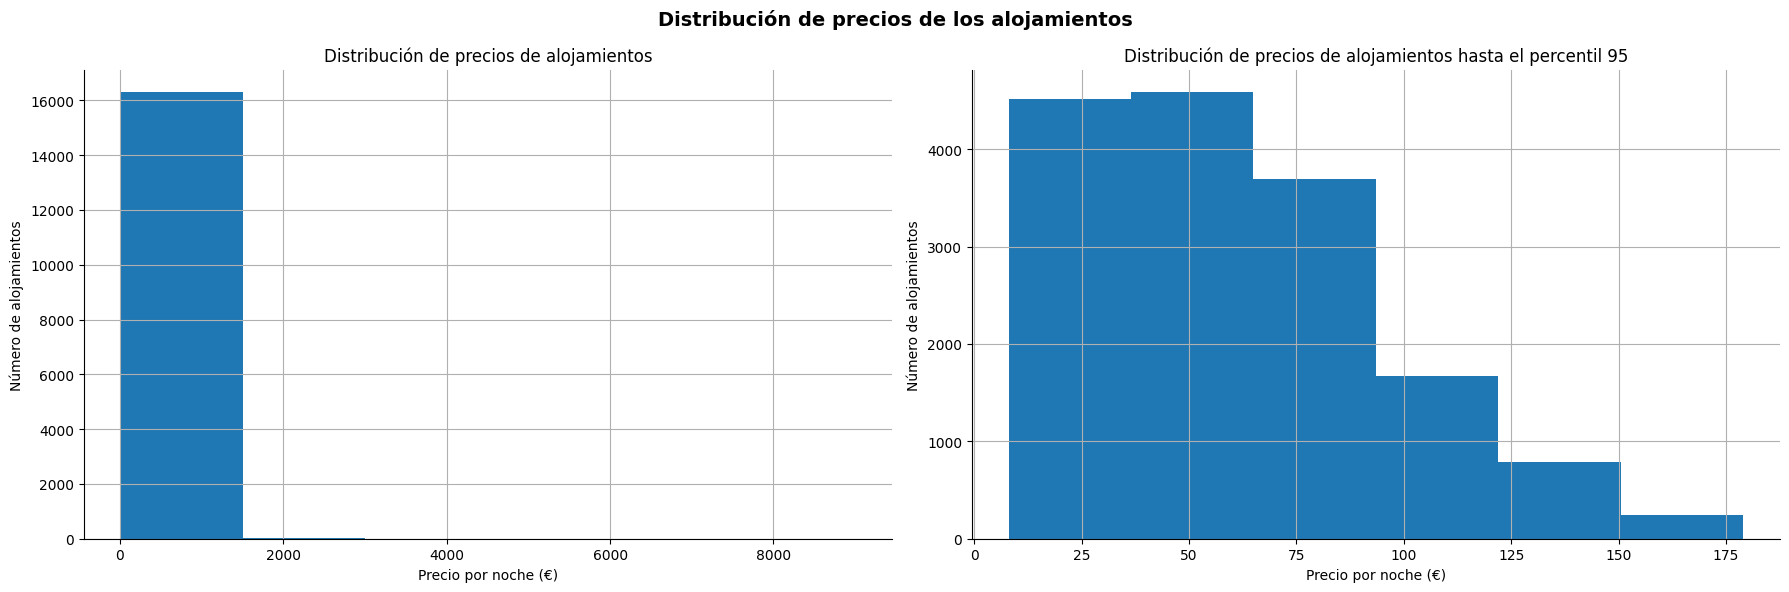

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))


precio_p95 = alojamientos["price"].quantile(0.95)

precios_filtrados = alojamientos.loc[
    alojamientos["price"] <= precio_p95,
    "price"
]


ax1.hist(alojamientos["price"], bins=6)
ax1.set_title("Distribución de precios de alojamientos")
ax1.set_xlabel("Precio por noche (€)")
ax1.set_ylabel("Número de alojamientos")
ax1.grid(True)
ax1.spines[["top", "right"]].set_visible(False)

ax2.hist(precios_filtrados, bins=6)
ax2.set_title("Distribución de precios de alojamientos hasta el percentil 95")
ax2.set_xlabel("Precio por noche (€)")
ax2.set_ylabel("Número de alojamientos")
ax2.grid(True)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución de precios de los alojamientos", fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

In [89]:
locales = pd.read_csv(DATA_DIR / 'locales.csv')
licencias = pd.read_csv(DATA_DIR / 'licencias.csv', parse_dates=["fecha_dec_lic"])
terrazas = pd.read_csv(DATA_DIR / 'terrazas.csv', parse_dates=["fecha_confir_ult_decreto_resol"])
actividades = pd.read_csv(DATA_DIR / 'actividades.csv', dtype={
    "id_division": "string",
    "id_epigrafe": "string",
})

In [90]:
# Validamos que los el nombre de los distritos en el fichero de alojamientos son los mismo que en el resto de ficheros

pd.concat([
    alojamientos.value_counts("neighbourhood_group_cleansed").sort_index().reset_index().iloc[:, 0],
    locales.value_counts("desc_distrito_local").sort_index().reset_index().iloc[:, 0],
], axis=1)

,neighbourhood_group_cleansed,desc_distrito_local
0,ARGANZUELA,ARGANZUELA
1,BARAJAS,BARAJAS
2,CARABANCHEL,CARABANCHEL
3,CENTRO,CENTRO
4,CHAMARTIN,CHAMARTIN
5,CHAMBERI,CHAMBERI
6,CIUDAD LINEAL,CIUDAD LINEAL
7,FUENCARRAL-EL PARDO,FUENCARRAL-EL PARDO
8,HORTALEZA,HORTALEZA
9,LATINA,LATINA


Vamos a ver la distribución de la cantidad de sillas en las terrazas, para crear un rango con el que relacionar las terrazas, nos quedamos con el percentil 95 de los datos porque existen varios outeliers que rompen el histogramo si no lo filtramos

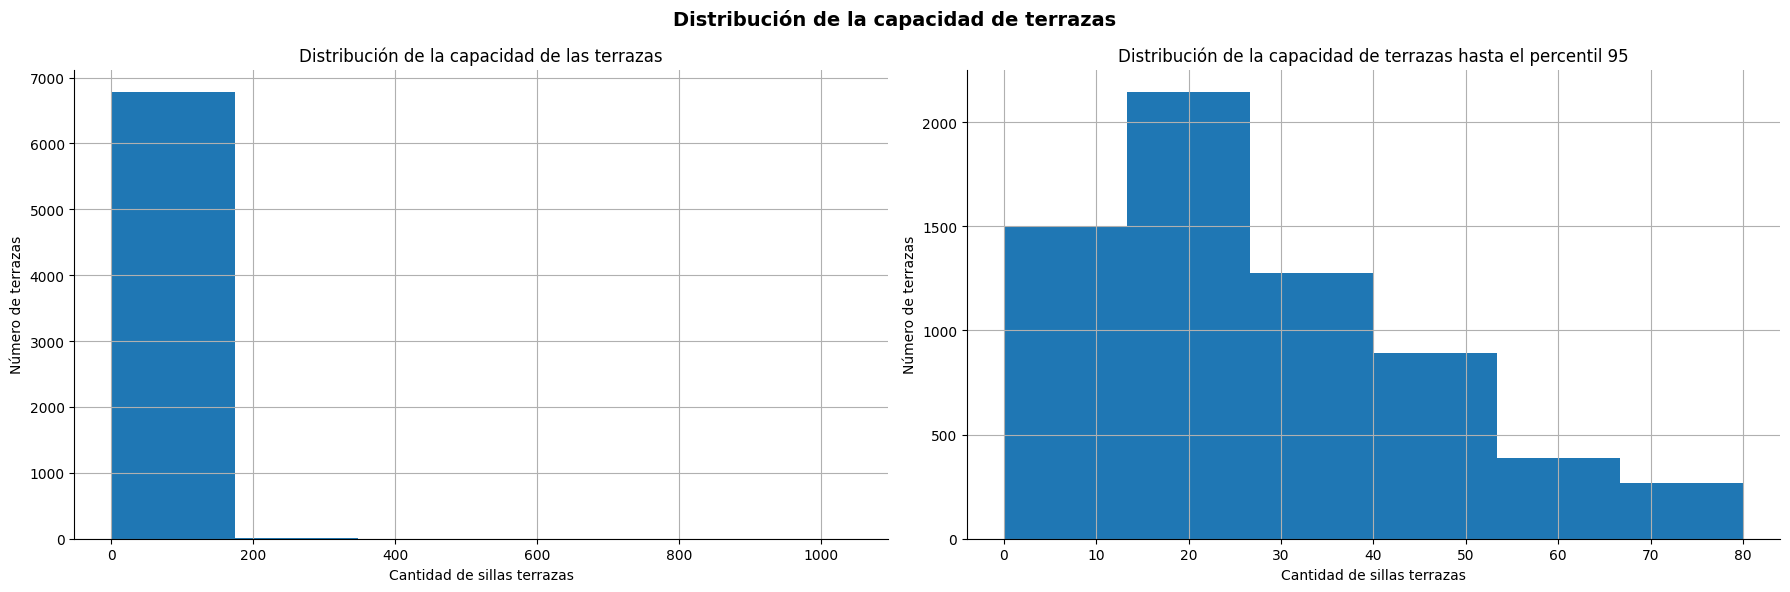

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

capacidad = terrazas[["sillas_ra", "sillas_es"]].max(axis=1)
capacidad_p95 = capacidad.quantile(0.95)
capacidad_filtrados = capacidad.loc[capacidad <= capacidad_p95]

ax1.hist(capacidad, bins=6)
ax1.set_title("Distribución de la capacidad de las terrazas")
ax1.set_xlabel("Cantidad de sillas terrazas")
ax1.set_ylabel("Número de terrazas")
ax1.grid(True)
ax1.spines[["top", "right"]].set_visible(False)


ax2.hist(capacidad_filtrados, bins=6)
ax2.set_title("Distribución de la capacidad de terrazas hasta el percentil 95")
ax2.set_xlabel("Cantidad de sillas terrazas")
ax2.set_ylabel("Número de terrazas")
ax2.grid(True)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución de la capacidad de terrazas", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [92]:
def make_locales(data, act, lic):
    """
    Prepara los nodos de Local para ser cargados en Neo4j.
    """
    def generar_horario(row):
        if pd.notna(row["hora_apertura1"]) and pd.notna(row["hora_cierre1"]):
            return row["hora_apertura1"] + " - " + row["hora_cierre1"]
        if pd.notna(row["hora_apertura2"]) and pd.notna(row["hora_cierre2"]):
            return row["hora_apertura2"] + " - " + row["hora_cierre2"]
        return pd.NA

    df = data.copy()

    df["node_id"] = "local:" + df["id_local"].astype(str)
    df["label"] = "Local"
    df = df.rename(columns={
        "desc_distrito_local": "barrio",
        "desc_barrio_local": "zona",
        "rotulo": "nombre",
    })

    df["direccion"] = df["clase_vial_acceso"].str.cat(df["desc_vial_acceso"], sep=" ")
    df["horario"] = df.apply(generar_horario, axis=1).fillna("DESCONOCIDO")

    act = (actividades
        .groupby("id_local")["desc_epigrafe"]
        .first()
        .rename("tipo_actividad")
        .reset_index())
    df = df.merge(act, on="id_local", how="left")
    # df["tipo_actividad"] = df["tipo_actividad"].fillna("NO INFORMADA")

    lic = licencias[["id_local", "ref_licencia", "desc_tipo_licencia", "desc_tipo_situacion_licencia"]]
    df = df.merge(lic, on="id_local", how="left")
    # df["licencias"] = df["licencias"].fillna({})

    return df[["node_id", "label", "barrio", "zona", "direccion", "nombre", "horario", "tipo_actividad", "ref_licencia", "desc_tipo_licencia", "desc_tipo_situacion_licencia", "lat", "lon"]]


def make_terrazas(data):
    """
    Prepara los nodos de Terraza para ser cargados en Neo4j.
    """
    df = data.copy()

    df["node_id"] = "terraza:" + df["id_terraza"].astype(str)
    df["label"] = "Terraza"
    df = df.rename(columns={
        "desc_distrito_local": "barrio",
        "desc_barrio_local": "zona",
        "rotulo": "nombre",
        "desc_periodo_terraza": "periodo_terraza",
        "desc_situacion_terraza": "estado_terraza"
    })

    df["direccion"] = df["desc_clase"].str.cat(df["desc_nombre"], sep=" ")
    df["capacidad"] =  df[["sillas_ra", "sillas_es"]].max(axis=1).astype(int)

    bins = [0, 15, 30, 45, 60, 80, float("inf")]
    labels = ["<=15", "(15-30]", "(30-45]", "(45-60]", "(60-80]", ">80"]
    df["rango_capacidad"] = pd.cut(df["capacidad"], bins=bins, labels=labels, include_lowest=True)

    return df[["node_id", "label", "barrio", "zona", "direccion", "nombre", "capacidad", "rango_capacidad", "periodo_terraza", "estado_terraza", "lat", "lon"]]


def make_alojamientos(data):
    """
    Prepara los nodos de Alojamiento para ser cargados en Neo4j.
    """
    df = data.copy()

    # Extraeccion de las coordenadas de latitud, longitud fuera del campo location
    df[["lat", "lon"]] = df.apply(lambda row: row["location"]["coordinates"], axis=1).to_list()


    df["node_id"] = "alojamiento:" + df["id"].astype(str)
    df["label"] = "Alojamiento"
    df = df.rename(columns={
        "neighbourhood_group_cleansed": "barrio",
        "name": "nombre",
        "price": "precio",
        "number_of_reviews": "reseñas",
        "bedrooms": "numero_habitaciones",
        "room_type": "tipo_habitacion",
        "amenities": "servicios"
    })

    bins = [0, 25, 50, 75, 100, 125, 150, float("inf")]
    labels = ["<=25", "(25-50]", "(50-75]", "(75-100]", "(100-125]", "(125-150]", ">150"]
    df["rango_precio"] = pd.cut(df["precio"], bins=bins, labels=labels, include_lowest=True)

    return df[["node_id", "label", "barrio", "nombre", "precio", "reseñas", "numero_habitaciones", "tipo_habitacion", "servicios", "rango_precio", "lat", "lon"]]

In [93]:
locales_nodes = make_locales(locales, actividades, licencias)
terrazas_nodes = make_terrazas(terrazas)
alojamientos_nodes = make_alojamientos(alojamientos)

In [94]:
pd.concat([
    locales_nodes.groupby("barrio").size().rename("locales"),
    terrazas_nodes.groupby("barrio").size().rename("terrazas"),
    alojamientos_nodes.groupby("barrio").size().rename("alojamientos")
], axis=1)

,locales,terrazas,alojamientos
barrio,,,
ARGANZUELA,9628,433,944
BARAJAS,2989,85,115
CARABANCHEL,17523,337,457
CENTRO,23779,763,8474
CHAMARTIN,11452,527,430
CHAMBERI,13598,685,1026
CIUDAD LINEAL,15675,290,405
FUENCARRAL-EL PARDO,11413,336,191
HORTALEZA,8802,243,230


In [95]:
# Número de locales, terrazas y alojamientos a samplear de forma aleatoria por cada barrio incluido en el grafo
SAMPLES=5

def sample_data(data, group_col, n_sample):
    """
    Función auxliar para samplear n_samples muestras por cada group_col.
    """
    df = data.copy()

    # Para que el modelo de ejemplo de Neo4j sea más sencillo de montar:
    #   1. Eliminamos los nodes con valores NA
    df = df.dropna()
    #   2. Omitimos los nombres, más genéricos para que los nodos sampleados sean más informativos
    df = df[~df["nombre"].isin(["SIN ACTIVIDAD", "ROTULO NO INFORMADO", "SR", "SIN ROTULO", "POR DETERMINAR", "A DETERMINAR", "SIN ESPECIFICAR"])]

    df = df.groupby(group_col).sample(n=n_sample, random_state=42)
    # Aleatorizamos los resultados
    return df.sample(frac=1, random_state=42)

# Escogemos 5 barrios para incluir en el grafo
barrios_sample = ["SALAMANCA", "PUENTE DE VALLECAS", "ARGANZUELA", "CHAMBERI", "RETIRO"]

# Sampleamos datos para los barrios seleccionados
locales_sample = sample_data(locales_nodes[locales_nodes["barrio"].isin(barrios_sample)], "barrio", SAMPLES)
terrazas_sample = sample_data(terrazas_nodes[terrazas_nodes["barrio"].isin(barrios_sample)], "barrio", SAMPLES)
alojamientos_sample = sample_data(alojamientos_nodes[alojamientos_nodes["barrio"].isin(barrios_sample)], "barrio", SAMPLES)

pd.concat([
    locales_sample.assign(tipo="Local")[["tipo", "nombre", "barrio", "lat", "lon"]].head(5),
    terrazas_sample.assign(tipo="Terraza")[["tipo", "nombre", "barrio", "lat", "lon"]].head(5),
    alojamientos_sample.assign(tipo="Alojamiento")[["tipo", "nombre", "barrio", "lat", "lon"]].head(5),
]).head(15)

,tipo,nombre,barrio,lat,lon
23522,Local,JMM-JOSE MARTINEZ MEDINA,CHAMBERI,40.439263,-3.713760
3293,Local,TIENDA DE ROPA DE VESTIR,RETIRO,40.417365,-3.669575
81159,Local,VIVIENDA,ARGANZUELA,40.394590,-3.696910
3914,Local,CLOKING,SALAMANCA,40.428949,-3.685098
58556,Local,LA MASERA DE PAPALANQUINDA,PUENTE DE VALLECAS,40.391325,-3.641581
2085,Terraza,SALES,CHAMBERI,40.441246,-3.715007
4530,Terraza,TARANTTELA,RETIRO,40.406335,-3.676147
6417,Terraza,MEGU,ARGANZUELA,40.403297,-3.711153
4589,Terraza,SUSHITA,SALAMANCA,40.428566,-3.683663
5661,Terraza,EL ENCUENTRO,PUENTE DE VALLECAS,40.394264,-3.666636


In [96]:
slug = lambda text: re.sub(r"[^A-Z0-9]+", "_", text).strip("_").lower()


def entity_records(locales, terrazas, alojamientos):
    """
    Convierte los dataframes a una lista de entidades.
    """
    records = []

    for row in locales.to_dict(orient="records"):
        records.append({
            "label": "Local",
            "node_id": row["node_id"],
            "barrio_id": "barrio:" + slug(row["barrio"]),
            "barrio_grafo": row["barrio"],
            "lat": row.get("lat"),
            "lon": row.get("lon"),
            "props": {
                "zona": row.get("zona"),
                "direccion": row.get("direccion"),
                "nombre": row.get("nombre"),
                "tipo_actividad": row.get("tipo_actividad"),
                "horario": row.get("horario"),
                "ref_licencia": row.get("ref_licencia"),
                "desc_tipo_licencia": row.get("desc_tipo_licencia"),
                "desc_tipo_situacion_licencia": row.get("desc_tipo_situacion_licencia"),
            },
            "relacion_attr": row.get("tipo_actividad"),
        })
    for row in terrazas.to_dict(orient="records"):
        records.append({
            "label": "Terraza",
            "node_id": row["node_id"],
            "barrio_id": "barrio:" + slug(row["barrio"]),
            "barrio_grafo": row["barrio"],
            "lat": row.get("lat"),
            "lon": row.get("lon"),
            "props": {
                "zona": row.get("zona"),
                "direccion": row.get("direccion"),
                "nombre": row.get("nombre"),
                "capacidad": row.get("capacidad"),
                "rango_capacidad": row.get("rango_capacidad"),
                "periodo_terraza": row.get("periodo_terraza"),
                "estado_terraza": row.get("estado_terraza"),
            },
            "relacion_attr": row.get("rango_capacidad"),
        })
    for row in alojamientos.to_dict(orient="records"):
        records.append({
            "label": "Alojamiento",
            "node_id": row["node_id"],
            "barrio_id": "barrio:" + slug(row["barrio"]),
            "barrio_grafo": row["barrio"],
            "lat": row.get("lat"),
            "lon": row.get("lon"),
            "props": {
                "nombre": row.get("nombre"),
                "precio": row.get("precio"),
                "numero_habitaciones": row.get("numero_habitaciones"),
                "reseñas": row.get("reseñas"),
                "servicios": row.get("servicios"),
                "tipo_habitacion": row.get("tipo_habitacion"),
                "rango_precio": row.get("rango_precio"),
            },
            "relacion_attr": row.get("rango_precio"),
        })

    return records

entities = entity_records(locales_sample, terrazas_sample, alojamientos_sample)

Agrupamos todas las coordenadas disponibles por barrio para calcular los centroides de cada barrio respecto a los que calcular las distancias.

In [97]:
coords_full = pd.concat([
    locales_nodes[["barrio", "lat", "lon"]],
    terrazas_nodes[["barrio", "lat", "lon"]],
    alojamientos_nodes[["barrio", "lat", "lon"]],
], ignore_index=True)

centroides = coords_full[coords_full["barrio"].isin(barrios_sample)].groupby("barrio")[["lat", "lon"]].mean().to_dict("index")

print("Centroides calculdados:")
print("=======================")
print(json.dumps(centroides, indent=2, ensure_ascii=False))

barrios_entities = []
for b in barrios_sample:
    barrios_entities.append({
        "label": "Barrio",
        "node_id": "barrio:" + slug(b),
        "lat": centroides[b]["lat"],
        "lon": centroides[b]["lon"],
        "props": {
            "nombre": b
        }
    })

Centroides calculdados:
{
  "ARGANZUELA": {
    "lat": 40.400469918281914,
    "lon": -3.6998100778856826
  },
  "CHAMBERI": {
    "lat": 40.43595408164769,
    "lon": -3.704465511214087
  },
  "PUENTE DE VALLECAS": {
    "lat": 40.38970988890635,
    "lon": -3.6589569051118067
  },
  "RETIRO": {
    "lat": 40.41034970607376,
    "lon": -3.675700605237662
  },
  "SALAMANCA": {
    "lat": 40.429152679344924,
    "lon": -3.676666699209168
  }
}


In [98]:
def is_null(value):
    """
    Detecta nulos escalares sin romper listas o diccionarios.
    """
    if value is None:
        return True
    if isinstance(value, (list, tuple, set, dict)):
        return False
    try:
        return bool(pd.isna(value))
    except Exception:
        return False


def cypher_key(key):
    """
    Escapa claves cuando tienen espacios, tildes o caracteres especiales.
    """
    key = str(key)
    if re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*", key):
        return key
    return f"`{key.replace("`", "``")}`"


def cypher_value(value):
    """
    Convierte a literales de Cypher.
    """
    if is_null(value):
        return "null"
    if isinstance(value, int):
        return str(int(value))
    if isinstance(value, float):
        return str(round(float(value), 5))
    if isinstance(value, (list, tuple, set)):
        cleaned = [x for x in value if not is_null(x)]
        return f"[{', '.join(cypher_value(x) for x in cleaned)}]"
    if isinstance(value, dict):
        cleaned = {k: v for k, v in value.items() if not is_null(v)}
        pairs = [f"{cypher_key(k)}: {cypher_value(v)}" for k, v in cleaned.items()]
        return "{" + ", ".join(pairs) + "}"
    text = str(value)
    text = text.replace("\\", "\\\\").replace('"', '\\"').replace("\n", " ")
    return f'"{text}"'

def cypher_map(props):
    cleaned = {k: v for k, v in props.items() if not is_null(v)}
    pairs = [f"{cypher_key(k)}: {cypher_value(v)}" for k, v in cleaned.items()]
    return "{" + ", ".join(pairs) + "}"


def merge_node(label, node_id, props, lat=None, lon=None):
    """
    Función auxiliar, MERGE de nodo por id y actualización de propiedades.
    """
    props = {k: v for k, v in props.items() if not is_null(v)}

    cypher_query = (
        f"MERGE (n:{label} {{id: {cypher_value(node_id)}}})\n"
        "SET n += " + cypher_map(props)
    )


    if lat is not None and lon is not None:
        cypher_query += f", n.location = point({{latitude: {lat}, longitude: {lon}}})"

    return cypher_query + ";"


def merge_rel(from_label, from_id, rel_type, to_label, to_id, *, props=None, umbral_cercania=None):
    """
    Función auxiliar, MERGE de relación entre dos nodos existentes.
    """
    props = props or {}

    cypher_query = f'MATCH (a:{from_label} {{id: {cypher_value(from_id)}}}), (b:{to_label} {{id: {cypher_value(to_id)}}})\n'

    if rel_type == 'Cercano_a':
        return (
            f'{cypher_query}'
            f'WHERE point.distance(a.location, b.location) <= {umbral_cercania}\n'
            f'MERGE (a)-[r:{rel_type}]->(b)\n'
            'SET r.distancia = round(point.distance(a.location, b.location));'
        )
    elif rel_type == 'Ubicado_en':
        return (
            f'{cypher_query}'
            f'MERGE (a)-[r:{rel_type}]->(b)\n'
            f'SET r.distancia = round(point.distance(a.location, b.location), 2);'
        )
    else:
        # Resto de realciones (ej: Relacionado_con)
        return (
            f'{cypher_query}'
            f'MERGE (a)-[r:{rel_type}]->(b)\n'
            f'SET r += {cypher_map(props)};'
        )

In [100]:
# El umbral en metros para considerar cercanos dos pares de Locales/Terrazas/Alojamientos
UMBRAL_CERCANIA_M = 500

cypher = [
    "// Carga dinámica de grafo para Neo4j",
    "// =======================================",
    "",
    "CREATE CONSTRAINT barrio_id IF NOT EXISTS FOR (n:Barrio) REQUIRE n.id IS UNIQUE;",
    "CREATE CONSTRAINT local_id IF NOT EXISTS FOR (n:Local) REQUIRE n.id IS UNIQUE;",
    "CREATE CONSTRAINT terraza_id IF NOT EXISTS FOR (n:Terraza) REQUIRE n.id IS UNIQUE;",
    "CREATE CONSTRAINT alojamiento_id IF NOT EXISTS FOR (n:Alojamiento) REQUIRE n.id IS UNIQUE;",
    "",
    "// Indices para los nodos puente",
    "// =======================================",
    "CREATE CONSTRAINT actividad_id IF NOT EXISTS FOR (n:Actividad) REQUIRE n.id IS UNIQUE;",
    "CREATE CONSTRAINT rangocapacidad_id IF NOT EXISTS FOR (n:RangoCapacidad) REQUIRE n.id IS UNIQUE;",
    "CREATE CONSTRAINT rangoprecio_id IF NOT EXISTS FOR (n:RangoPrecio) REQUIRE n.id IS UNIQUE;",
    "",
    "// ---------- Nodos Barrio, Local, Terraza y Alojamiento ----------"
]

for e in barrios_entities + entities:
    cypher.append(merge_node(e["label"], e["node_id"], e["props"], e["lat"], e["lon"]))


cypher.append("\n// ---------- Relaciones Ubicado_en ----------")
for e in entities:
    cypher.append(merge_rel(
        e["label"],
        e["node_id"],
        "Ubicado_en",
        "Barrio",
        e["barrio_id"],
    ))

cypher.append("\n// ---------- Relaciones Cercano_a: distancia <= 500 m ----------")
near_count = 0
for e1, e2 in combinations(entities, 2):
    # Precalculamos la distancia en python y solo añadimos los pares de nodos que cumplen la condición
    # para aligerar la carga de trabajo de neo4j
    d = haversine((e1["lat"], e1["lon"]), (e2["lat"], e2["lon"]), unit="m")
    if d is not None and d <= UMBRAL_CERCANIA_M:
        cypher.append(merge_rel(
            e1["label"],
            e1["node_id"],
            "Cercano_a",
            e2["label"],
            e2["node_id"],
            umbral_cercania=UMBRAL_CERCANIA_M
        ))
        near_count += 1

cypher.append("\n// ---------- Relaciones Relacionado_con ----------")
relacionado_count = 0
rel_specs = {
    "Local": ("tipo_actividad", "Actividad", "tipo de actividad"),
    "Terraza": ("rango_capacidad", "RangoCapacidad", "capacidad de terraza"),
    "Alojamiento": ("rango_precio", "RangoPrecio", "rango de precio"),
}

for e in entities:
    label = e["label"]

    if label in rel_specs:
        attr, hub_label, motivo_base = rel_specs[label]
        valor = e["props"].get(attr)

        if valor and str(valor).strip() and str(valor).strip().lower() != "nan":
            # Id único para el nodo puente (p.ej: "actividad:bar")
            hub_id = f"{hub_label.lower()}:{slug(str(valor))}"

            # Crea o recupera el nodo puente
            cypher_hub = merge_node(
                label=hub_label,
                node_id=hub_id,
                props={"valor": valor}
            )
            cypher.append(cypher_hub)

            # Une el Local con el nodo puente
            cypher_rel = merge_rel(
                from_label=label,
                from_id=e["node_id"],
                rel_type="Relacionado_con",  # Mantenemos el nombre exacto que pide la tarea
                to_label=hub_label,
                to_id=hub_id,
                props={"motivo": f"Mismo {motivo_base}: {valor}"} # El atributo que pide la tarea
            )
            cypher.append(cypher_rel)

            relacionado_count += 1


print("Resumen:")
print("========")
print(f"  Nodos Barrio:       {len(barrios_sample)}")
print(f"  Nodos Local:        {len(locales_sample)}")
print(f"  Nodos Terraza:      {len(terrazas_sample)}")
print(f"  Nodos Alojamiento:  {len(alojamientos_sample)}")
print(f"  Rel. Ubicado_en:    {len(entities)}")
print(f"  Rel. Cercano_a:     {near_count}")
print(f"  Rel. Relacionado_con: {relacionado_count}")

Resumen:
  Nodos Barrio:       5
  Nodos Local:        25
  Nodos Terraza:      25
  Nodos Alojamiento:  25
  Rel. Ubicado_en:    75
  Rel. Cercano_a:     87
  Rel. Relacionado_con: 75


### Guardar el conjunto de datos resultante

In [101]:
(DATA_DIR / 'barrios_grafo.cypher').write_text("\n".join(cypher), encoding="utf-8")

93933